In [1]:
import pandas as pd

file_path = 'df_prop_binario.csv'
df = pd.read_csv(file_path)

df.head()

,ID_FAM_ANON,VL_RENDA_MEDIA_FAM,IN_TRABALHO_INFANTIL_FAM,CO_MUNIC_IBGE_2_FAM,CO_MUNIC_IBGE_5_FAM,IN_FORMULARIO_SUP2_FAM,QT_PESSOAS_DOMIC_FAM,QT_FAMILIAS_DOMIC_FAM,CO_ESPECIE_DOMIC_FAM,CO_LOCAL_DOMIC_FAM,...,PCT_PES_DEFICIENCIA,TEM_CRIANCA_SEM_ESCOLA,TEM_ADOLESCENTE_SEM_ESCOLA,PCT_PES_ANALFABETA,PCT_ADULTO_NUNCA_FREQ_ESCOLA,PCT_7A18_ESCOLA_PUBLICA,PCT_MENOR6_FORA_CRECHE_PRE,classe_renda,y_bin,classe_risco_qualificacao
0,3619572,1962.0,2,29,25303,0,3,1,1,2,...,0.0,0,0,0.000000,0.000000,0.666667,0.0,2,1,renda formal per capita (CNIS) > ½ SM
1,2307857,745.0,2,26,2902,0,2,1,1,1,...,0.0,0,0,0.000000,0.000000,0.500000,0.0,1,0,renda formal per capita (CNIS) ≤ ½ SM
2,5051602,155.0,2,33,1702,0,1,1,1,1,...,0.0,0,0,0.000000,0.000000,0.000000,0.0,0,0,renda formal per capita (CNIS) ≤ ½ SM
3,32816,725.0,2,11,346,0,4,2,1,1,...,0.0,0,0,0.333333,0.000000,0.666667,0.0,1,0,renda formal per capita (CNIS) ≤ ½ SM
4,2320026,1629.0,2,26,3306,0,3,1,1,2,...,0.0,0,0,0.333333,0.333333,0.000000,0.0,2,1,renda formal per capita (CNIS) > ½ SM


In [2]:
df.columns

Index(['ID_FAM_ANON', 'VL_RENDA_MEDIA_FAM', 'IN_TRABALHO_INFANTIL_FAM',
       'CO_MUNIC_IBGE_2_FAM', 'CO_MUNIC_IBGE_5_FAM', 'IN_FORMULARIO_SUP2_FAM',
       'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM', 'CO_ESPECIE_DOMIC_FAM',
       'CO_LOCAL_DOMIC_FAM', 'QT_COMODOS_DOMIC_FAM',
       'QT_COMODOS_DORMITORIO_FAM', 'CO_MATERIAL_DOMIC_FAM',
       'CO_MATERIAL_PISO_FAM', 'CO_AGUA_CANALIZADA_FAM',
       'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM',
       'CO_ESCOA_SANITARIO_DOMIC_FAM', 'CO_ILUMINACAO_DOMIC_FAM',
       'IN_FAMILIA_INDIGENA_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM',
       'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
       'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
       'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
       'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
       'CO_TRABALHOU_SEMANA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
       'CO_AGRICULTURA_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
       'CO_TRABALHO_

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 54 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   ID_FAM_ANON                   1000000 non-null  int64  
 1   VL_RENDA_MEDIA_FAM            1000000 non-null  float64
 2   IN_TRABALHO_INFANTIL_FAM      1000000 non-null  int64  
 3   CO_MUNIC_IBGE_2_FAM           1000000 non-null  int64  
 4   CO_MUNIC_IBGE_5_FAM           1000000 non-null  int64  
 5   IN_FORMULARIO_SUP2_FAM        1000000 non-null  int64  
 6   QT_PESSOAS_DOMIC_FAM          1000000 non-null  int64  
 7   QT_FAMILIAS_DOMIC_FAM         1000000 non-null  int64  
 8   CO_ESPECIE_DOMIC_FAM          1000000 non-null  int64  
 9   CO_LOCAL_DOMIC_FAM            1000000 non-null  int64  
 10  QT_COMODOS_DOMIC_FAM          1000000 non-null  int64  
 11  QT_COMODOS_DORMITORIO_FAM     1000000 non-null  int64  
 12  CO_MATERIAL_DOMIC_FAM        

In [4]:
(df["CO_PRINCIPAL_TRAB_MEMB"] == 9).any()

np.True_

In [5]:
(df["CO_PRINCIPAL_TRAB_MEMB"] == 9).sum()

np.int64(200)

In [6]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
)

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression


In [7]:
df['classe_renda'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1000000 entries, 0 to 999999
Series name: classe_renda
Non-Null Count    Dtype
--------------    -----
1000000 non-null  int64
dtypes: int64(1)
memory usage: 7.6 MB


In [8]:
df['y_bin'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1000000 entries, 0 to 999999
Series name: y_bin
Non-Null Count    Dtype
--------------    -----
1000000 non-null  int64
dtypes: int64(1)
memory usage: 7.6 MB


## Separação treino e teste

In [9]:
df["ID_FAM_ANON"].is_unique

True

In [10]:
df.columns

Index(['ID_FAM_ANON', 'VL_RENDA_MEDIA_FAM', 'IN_TRABALHO_INFANTIL_FAM',
       'CO_MUNIC_IBGE_2_FAM', 'CO_MUNIC_IBGE_5_FAM', 'IN_FORMULARIO_SUP2_FAM',
       'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM', 'CO_ESPECIE_DOMIC_FAM',
       'CO_LOCAL_DOMIC_FAM', 'QT_COMODOS_DOMIC_FAM',
       'QT_COMODOS_DORMITORIO_FAM', 'CO_MATERIAL_DOMIC_FAM',
       'CO_MATERIAL_PISO_FAM', 'CO_AGUA_CANALIZADA_FAM',
       'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM',
       'CO_ESCOA_SANITARIO_DOMIC_FAM', 'CO_ILUMINACAO_DOMIC_FAM',
       'IN_FAMILIA_INDIGENA_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM',
       'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
       'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
       'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
       'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
       'CO_TRABALHOU_SEMANA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
       'CO_AGRICULTURA_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
       'CO_TRABALHO_

In [11]:
colunas_excluir = [
    "classe_renda",
    "y_bin",
    "classe_risco_qualificacao",
    "VL_RENDA_MEDIA_FAM",
    "ID_FAM_ANON"
]

X = df.drop(columns=colunas_excluir)
y = df["y_bin"]


In [12]:
df.columns

Index(['ID_FAM_ANON', 'VL_RENDA_MEDIA_FAM', 'IN_TRABALHO_INFANTIL_FAM',
       'CO_MUNIC_IBGE_2_FAM', 'CO_MUNIC_IBGE_5_FAM', 'IN_FORMULARIO_SUP2_FAM',
       'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM', 'CO_ESPECIE_DOMIC_FAM',
       'CO_LOCAL_DOMIC_FAM', 'QT_COMODOS_DOMIC_FAM',
       'QT_COMODOS_DORMITORIO_FAM', 'CO_MATERIAL_DOMIC_FAM',
       'CO_MATERIAL_PISO_FAM', 'CO_AGUA_CANALIZADA_FAM',
       'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM',
       'CO_ESCOA_SANITARIO_DOMIC_FAM', 'CO_ILUMINACAO_DOMIC_FAM',
       'IN_FAMILIA_INDIGENA_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM',
       'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
       'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
       'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
       'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
       'CO_TRABALHOU_SEMANA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
       'CO_AGRICULTURA_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
       'CO_TRABALHO_

In [13]:
X.columns

Index(['IN_TRABALHO_INFANTIL_FAM', 'CO_MUNIC_IBGE_2_FAM',
       'CO_MUNIC_IBGE_5_FAM', 'IN_FORMULARIO_SUP2_FAM', 'QT_PESSOAS_DOMIC_FAM',
       'QT_FAMILIAS_DOMIC_FAM', 'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM',
       'QT_COMODOS_DOMIC_FAM', 'QT_COMODOS_DORMITORIO_FAM',
       'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM',
       'CO_AGUA_CANALIZADA_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM',
       'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
       'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_INDIGENA_FAM',
       'IN_FAMILIA_QUILOMBOLA_FAM', 'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB',
       'CO_SEXO_PESSOA', 'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA',
       'CO_DEFICIENCIA_MEMB', 'CO_SABE_LER_ESCREVER_MEMB',
       'IN_FREQUENTA_ESCOLA_MEMB', 'CO_CURSO_FREQUENTA_MEMB',
       'CO_CURSO_FREQ_PESSOA_MEMB', 'CO_TRABALHOU_SEMANA_MEMB',
       'CO_AFASTADO_TRAB_MEMB', 'CO_AGRICULTURA_TRAB_MEMB',
       'CO_PRINCIPAL_TRAB_MEMB', 'CO_TRABALHO_12_MESES_MEMB', 'QTD_PESSOAS',
       'PCT_1

## Análise de correlação das variáveis

In [14]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# ---- 1) Listas das categorias ----

cat_num_cols = [
    'IN_TRABALHO_INFANTIL_FAM', 'IN_FORMULARIO_SUP2_FAM',
    'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM',
    'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM',
    'CO_AGUA_CANALIZADA_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM',
    'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
    'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_INDIGENA_FAM',
    'IN_FAMILIA_QUILOMBOLA_FAM', 'IN_PARC_MDS_FAM',
    'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
    'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
    'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
    'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
    'CO_TRABALHOU_SEMANA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
    'CO_AGRICULTURA_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
    'CO_TRABALHO_12_MESES_MEMB',
]

bool_cols = [
    'TEM_CRIANCA_SEM_ESCOLA',
    'TEM_ADOLESCENTE_SEM_ESCOLA',
    ]

pct_cols = [
    'PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11',
    'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29',
    'PCT_ADULTOS_30A59', 'PCT_IDOSOS_60A64',
    'PCT_IDOSOS_BPC', 'PCT_PES_DEFICIENCIA', 'PCT_PES_ANALFABETA',
    'PCT_ADULTO_NUNCA_FREQ_ESCOLA', 'PCT_7A18_ESCOLA_PUBLICA',
    'PCT_MENOR6_FORA_CRECHE_PRE', 
]


quant_cols = [
    'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM',
    'QT_COMODOS_DOMIC_FAM', 'QT_COMODOS_DORMITORIO_FAM',
    'IDADE_REFERENCIA',
]

# Conjuntos auxiliares para testar tipo rapidamente
cat_all = cat_num_cols + bool_cols    # tratadas como categóricas
num_all = quant_cols + pct_cols                    # tratadas como numéricas

set_cat = set(cat_all)
set_num = set(num_all)

# Todas as variáveis consideradas
all_vars = cat_all + num_all

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Selecionar apenas quantitativas
df_quant = X[quant_cols + pct_cols]

# Matriz de correlação Pearson
corr_quant = df_quant.corr(method='pearson')

# Máscara acima da diagonal
mask = np.triu(np.ones_like(corr_quant, dtype=bool))

plt.figure(figsize=(10, 5))
sns.heatmap(
    corr_quant.round(2),
    annot=False,
    cmap='coolwarm',
    mask=mask
)
plt.title("Correlação (Pearson) – Variáveis Quantitativas")
plt.show()


NameError: name 'df_fam_ivcad_rf' is not defined

In [16]:
# Converter matriz para formato longo (var1, var2, corr)
corr_pairs = (
    corr_quant
        .where(np.triu(np.ones(corr_quant.shape), k=1).astype(bool))  # apenas acima da diagonal
        .stack()
        .reset_index()
)
corr_pairs.columns = ['var1', 'var2', 'corr']

# Ordenar pelas correlações mais fortes (em valor absoluto)
corr_pairs_sorted = corr_pairs.reindex(corr_pairs['corr'].abs().sort_values(ascending=False).index)

# Mostrar top 20
corr_pairs_sorted.head(20)


,var1,var2,corr
31,QT_COMODOS_DOMIC_FAM,QT_COMODOS_DORMITORIO_FAM,0.728853
98,PCT_ADOLESCENTES_12A18,PCT_7A18_ESCOLA_PUBLICA,0.720760
80,PCT_1_INFANCIA,PCT_MENOR6_FORA_CRECHE_PRE,0.703054
100,PCT_JOVENS_19A29,PCT_ADULTOS_30A59,-0.565503
89,PCT_CRIANCAS_7A11,PCT_7A18_ESCOLA_PUBLICA,0.542228
130,PCT_PES_ANALFABETA,PCT_ADULTO_NUNCA_FREQ_ESCOLA,0.489142
64,IDADE_REFERENCIA,PCT_IDOSOS_BPC,0.443160
58,IDADE_REFERENCIA,PCT_1_INFANCIA,-0.406536
61,IDADE_REFERENCIA,PCT_JOVENS_19A29,-0.378464
14,QT_PESSOAS_DOMIC_FAM,PCT_7A18_ESCOLA_PUBLICA,0.372092


In [17]:
THR_CORR = 0.80

corr_fortes = corr_pairs_sorted[
    corr_pairs_sorted["corr"].abs() >= THR_CORR
].copy()

corr_fortes

,var1,var2,corr


In [18]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    t = pd.crosstab(x, y)
    if t.shape[0] <= 1 or t.shape[1] <= 1:
        return np.nan
    chi2, p, dof, expected = chi2_contingency(t)
    n = t.to_numpy().sum()
    r, k = t.shape
    return np.sqrt(chi2 / (n*(min(r,k)-1)))


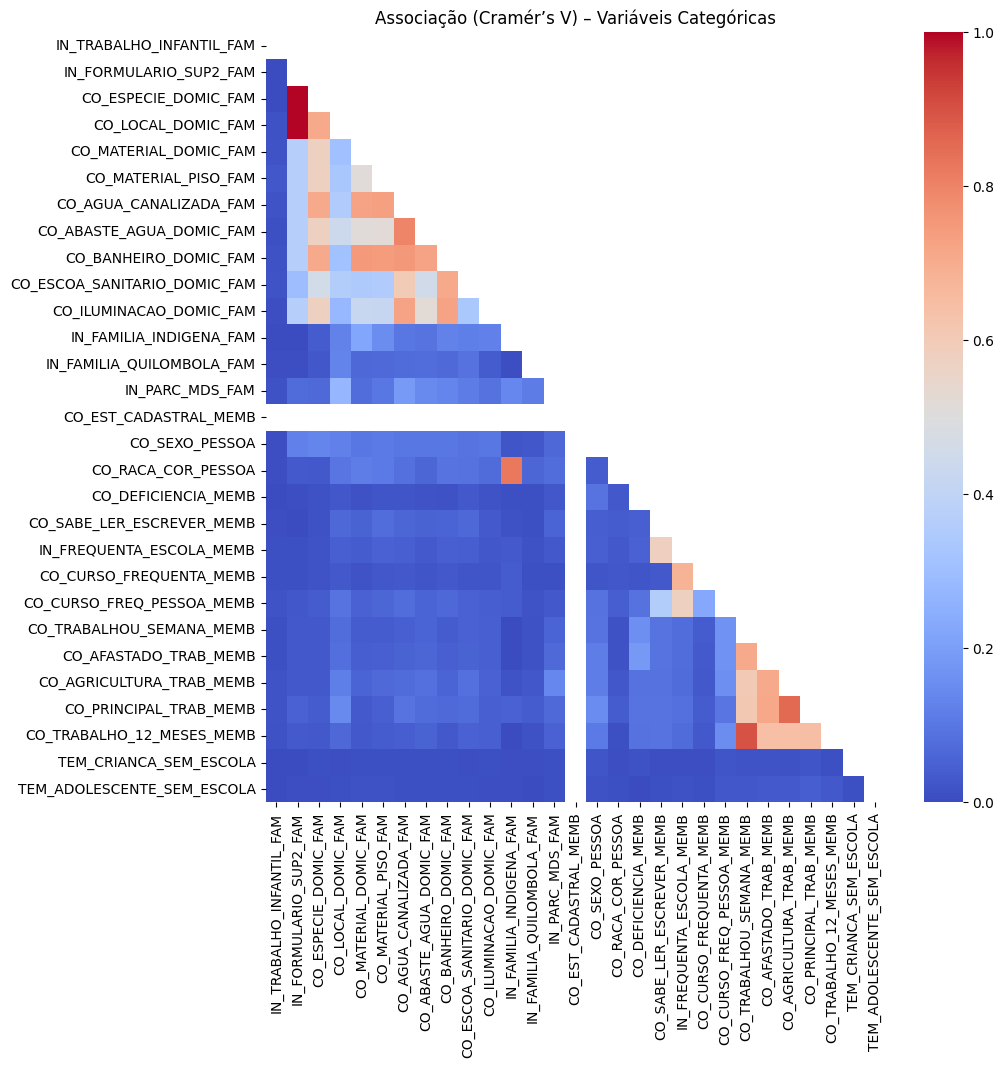

In [19]:
# Selecionar todas as categóricas
df_cat = X[cat_num_cols + bool_cols]

# Matriz vazia
cramers_mat = pd.DataFrame(index=df_cat.columns, columns=df_cat.columns)

# Preencher matriz
for c1 in df_cat.columns:
    for c2 in df_cat.columns:
        if c1 == c2:
            cramers_mat.loc[c1, c2] = 1
        else:
            cramers_mat.loc[c1, c2] = cramers_v(df_cat[c1], df_cat[c2])

# Converter para float
cramers_mat = cramers_mat.astype(float)

# Máscara
mask = np.triu(np.ones_like(cramers_mat, dtype=bool))

plt.figure(figsize=(10, 10))
sns.heatmap(
    cramers_mat,
    annot=False,
    cmap='coolwarm',
    mask=mask,
    vmax=1,
    vmin=0
)
plt.title("Associação (Cramér’s V) – Variáveis Categóricas")
plt.show()


In [20]:
import numpy as np
import pandas as pd

# partindo de cramers_mat já calculada

# 1) Pegar só a parte acima da diagonal para evitar duplicação
cramers_pairs = (
    cramers_mat
        .where(np.triu(np.ones(cramers_mat.shape), k=1).astype(bool))  # mantém só acima da diagonal
        .stack()                                                       # transforma em série longa
        .reset_index()
)

cramers_pairs.columns = ['var1', 'var2', 'cramers_v']

# 2) Ordenar pelas maiores associações
cramers_pairs_sorted = cramers_pairs.sort_values('cramers_v', ascending=False)

# 3) Ver as 30 maiores associações
print("Top 30 pares com maior Cramér's V:")
print(cramers_pairs_sorted.head(10))


Top 30 pares com maior Cramér's V:
                         var1                       var2  cramers_v
27     IN_FORMULARIO_SUP2_FAM       CO_ESPECIE_DOMIC_FAM   0.999804
28     IN_FORMULARIO_SUP2_FAM         CO_LOCAL_DOMIC_FAM   0.999786
360  CO_TRABALHOU_SEMANA_MEMB  CO_TRABALHO_12_MESES_MEMB   0.900185
368  CO_AGRICULTURA_TRAB_MEMB     CO_PRINCIPAL_TRAB_MEMB   0.858777
245   IN_FAMILIA_INDIGENA_FAM         CO_RACA_COR_PESSOA   0.826024
147    CO_AGUA_CANALIZADA_FAM   CO_ABASTE_AGUA_DOMIC_FAM   0.799441
148    CO_AGUA_CANALIZADA_FAM      CO_BANHEIRO_DOMIC_FAM   0.750885
105     CO_MATERIAL_DOMIC_FAM      CO_BANHEIRO_DOMIC_FAM   0.747036
127      CO_MATERIAL_PISO_FAM      CO_BANHEIRO_DOMIC_FAM   0.742778
125      CO_MATERIAL_PISO_FAM     CO_AGUA_CANALIZADA_FAM   0.733689


In [21]:
# Definir um limiar para "associação muito alta"
threshold = 0.80

cramers_high = cramers_pairs_sorted[cramers_pairs_sorted['cramers_v'] >= threshold]

print(f"\nPares com Cramér's V >= {threshold}:")
print(cramers_high)



Pares com Cramér's V >= 0.8:
                         var1                       var2  cramers_v
27     IN_FORMULARIO_SUP2_FAM       CO_ESPECIE_DOMIC_FAM   0.999804
28     IN_FORMULARIO_SUP2_FAM         CO_LOCAL_DOMIC_FAM   0.999786
360  CO_TRABALHOU_SEMANA_MEMB  CO_TRABALHO_12_MESES_MEMB   0.900185
368  CO_AGRICULTURA_TRAB_MEMB     CO_PRINCIPAL_TRAB_MEMB   0.858777
245   IN_FAMILIA_INDIGENA_FAM         CO_RACA_COR_PESSOA   0.826024


In [22]:
X = X.drop(columns=['IN_FORMULARIO_SUP2_FAM', 'CO_TRABALHOU_SEMANA_MEMB', 'CO_AGRICULTURA_TRAB_MEMB', 'IN_FAMILIA_INDIGENA_FAM'])

In [23]:
X.columns

Index(['IN_TRABALHO_INFANTIL_FAM', 'CO_MUNIC_IBGE_2_FAM',
       'CO_MUNIC_IBGE_5_FAM', 'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM',
       'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM', 'QT_COMODOS_DOMIC_FAM',
       'QT_COMODOS_DORMITORIO_FAM', 'CO_MATERIAL_DOMIC_FAM',
       'CO_MATERIAL_PISO_FAM', 'CO_AGUA_CANALIZADA_FAM',
       'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM',
       'CO_ESCOA_SANITARIO_DOMIC_FAM', 'CO_ILUMINACAO_DOMIC_FAM',
       'IN_FAMILIA_QUILOMBOLA_FAM', 'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB',
       'CO_SEXO_PESSOA', 'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA',
       'CO_DEFICIENCIA_MEMB', 'CO_SABE_LER_ESCREVER_MEMB',
       'IN_FREQUENTA_ESCOLA_MEMB', 'CO_CURSO_FREQUENTA_MEMB',
       'CO_CURSO_FREQ_PESSOA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
       'CO_PRINCIPAL_TRAB_MEMB', 'CO_TRABALHO_12_MESES_MEMB', 'QTD_PESSOAS',
       'PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11', 'PCT_ADOLESCENTES_12A18',
       'PCT_JOVENS_19A29', 'PCT_ADULTOS_30A59', 'PCT_IDOSOS_60A6

In [24]:
X.head()

,IN_TRABALHO_INFANTIL_FAM,CO_MUNIC_IBGE_2_FAM,CO_MUNIC_IBGE_5_FAM,QT_PESSOAS_DOMIC_FAM,QT_FAMILIAS_DOMIC_FAM,CO_ESPECIE_DOMIC_FAM,CO_LOCAL_DOMIC_FAM,QT_COMODOS_DOMIC_FAM,QT_COMODOS_DORMITORIO_FAM,CO_MATERIAL_DOMIC_FAM,...,PCT_ADULTOS_30A59,PCT_IDOSOS_60A64,PCT_IDOSOS_BPC,PCT_PES_DEFICIENCIA,TEM_CRIANCA_SEM_ESCOLA,TEM_ADOLESCENTE_SEM_ESCOLA,PCT_PES_ANALFABETA,PCT_ADULTO_NUNCA_FREQ_ESCOLA,PCT_7A18_ESCOLA_PUBLICA,PCT_MENOR6_FORA_CRECHE_PRE
0,2,29,25303,3,1,1,2,5,2,1,...,0.333333,0.0,0.000000,0.0,0,0,0.000000,0.000000,0.666667,0.0
1,2,26,2902,2,1,1,1,5,2,1,...,0.500000,0.0,0.000000,0.0,0,0,0.000000,0.000000,0.500000,0.0
2,2,33,1702,1,1,1,1,3,1,1,...,0.000000,0.0,0.000000,0.0,0,0,0.000000,0.000000,0.000000,0.0
3,2,11,346,4,2,1,1,5,2,3,...,0.333333,0.0,0.000000,0.0,0,0,0.333333,0.000000,0.666667,0.0
4,2,26,3306,3,1,1,2,9,4,1,...,0.666667,0.0,0.333333,0.0,0,0,0.333333,0.333333,0.000000,0.0


In [25]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 45 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   IN_TRABALHO_INFANTIL_FAM      1000000 non-null  int64  
 1   CO_MUNIC_IBGE_2_FAM           1000000 non-null  int64  
 2   CO_MUNIC_IBGE_5_FAM           1000000 non-null  int64  
 3   QT_PESSOAS_DOMIC_FAM          1000000 non-null  int64  
 4   QT_FAMILIAS_DOMIC_FAM         1000000 non-null  int64  
 5   CO_ESPECIE_DOMIC_FAM          1000000 non-null  int64  
 6   CO_LOCAL_DOMIC_FAM            1000000 non-null  int64  
 7   QT_COMODOS_DOMIC_FAM          1000000 non-null  int64  
 8   QT_COMODOS_DORMITORIO_FAM     1000000 non-null  int64  
 9   CO_MATERIAL_DOMIC_FAM         1000000 non-null  int64  
 10  CO_MATERIAL_PISO_FAM          1000000 non-null  int64  
 11  CO_AGUA_CANALIZADA_FAM        1000000 non-null  int64  
 12  CO_ABASTE_AGUA_DOMIC_FAM     

## Pre-processamento
### Detectando as colunas categóricas binárias e multicategóricas

In [26]:
X.columns

Index(['IN_TRABALHO_INFANTIL_FAM', 'CO_MUNIC_IBGE_2_FAM',
       'CO_MUNIC_IBGE_5_FAM', 'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM',
       'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM', 'QT_COMODOS_DOMIC_FAM',
       'QT_COMODOS_DORMITORIO_FAM', 'CO_MATERIAL_DOMIC_FAM',
       'CO_MATERIAL_PISO_FAM', 'CO_AGUA_CANALIZADA_FAM',
       'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM',
       'CO_ESCOA_SANITARIO_DOMIC_FAM', 'CO_ILUMINACAO_DOMIC_FAM',
       'IN_FAMILIA_QUILOMBOLA_FAM', 'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB',
       'CO_SEXO_PESSOA', 'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA',
       'CO_DEFICIENCIA_MEMB', 'CO_SABE_LER_ESCREVER_MEMB',
       'IN_FREQUENTA_ESCOLA_MEMB', 'CO_CURSO_FREQUENTA_MEMB',
       'CO_CURSO_FREQ_PESSOA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
       'CO_PRINCIPAL_TRAB_MEMB', 'CO_TRABALHO_12_MESES_MEMB', 'QTD_PESSOAS',
       'PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11', 'PCT_ADOLESCENTES_12A18',
       'PCT_JOVENS_19A29', 'PCT_ADULTOS_30A59', 'PCT_IDOSOS_60A6

In [27]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Listas de cada categoria
cat_num_cols = [
    'IN_TRABALHO_INFANTIL_FAM', 
    'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM',
    'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM',
    'CO_AGUA_CANALIZADA_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM',
    'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
    'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM', 
    'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
    'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
    'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB', 'CO_CURSO_FREQUENTA_MEMB', 
    'CO_CURSO_FREQ_PESSOA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
    'CO_PRINCIPAL_TRAB_MEMB', 'CO_TRABALHO_12_MESES_MEMB',
    ]

bool_cols = [
        'TEM_CRIANCA_SEM_ESCOLA',
        'TEM_ADOLESCENTE_SEM_ESCOLA',
        ]

pct_cols = [
         'PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11',
      'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29',
      'PCT_ADULTOS_30A59', 'PCT_IDOSOS_60A64',
      'PCT_IDOSOS_BPC', 'PCT_PES_DEFICIENCIA', 'PCT_PES_ANALFABETA',
       'PCT_ADULTO_NUNCA_FREQ_ESCOLA', 'PCT_7A18_ESCOLA_PUBLICA',
       'PCT_MENOR6_FORA_CRECHE_PRE',
    ]

quant_cols = [
        'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM',
        'QT_COMODOS_DOMIC_FAM', 'QT_COMODOS_DORMITORIO_FAM',
        'QTD_PESSOAS', 'IDADE_REFERENCIA',
    ]

geo_cols = ['CO_MUNIC_IBGE_2_FAM', 'CO_MUNIC_IBGE_5_FAM']


In [28]:
# Garante que as listas só pegam colunas que realmente existem
cat_num_cols_eff = [c for c in cat_num_cols if c in X.columns]
bool_cols_eff    = [c for c in bool_cols    if c in X.columns]
pct_cols_eff     = [c for c in pct_cols     if c in X.columns]
quant_cols_eff   = [c for c in quant_cols   if c in X.columns]
geo_cols_eff     = [c for c in geo_cols     if c in X.columns]

# Detectar binárias e multicategóricas dentro de cat_num_cols
binary_cols = []
multicat_cols = []

for col in cat_num_cols_eff:
    n_unique = X[col].nunique()
    if n_unique == 2:
        binary_cols.append(col)
    elif n_unique > 2:
        multicat_cols.append(col)

print("Binárias:", binary_cols)
print("Multicategóricas:", multicat_cols)

Binárias: ['IN_TRABALHO_INFANTIL_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM', 'CO_SEXO_PESSOA', 'CO_DEFICIENCIA_MEMB', 'CO_SABE_LER_ESCREVER_MEMB']
Multicategóricas: ['CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM', 'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM', 'CO_AGUA_CANALIZADA_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM', 'CO_ILUMINACAO_DOMIC_FAM', 'IN_PARC_MDS_FAM', 'CO_RACA_COR_PESSOA', 'IN_FREQUENTA_ESCOLA_MEMB', 'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB', 'CO_AFASTADO_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB', 'CO_TRABALHO_12_MESES_MEMB']


In [29]:
# Pipeline quantitativas contínuas
pipeline_quant = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", MinMaxScaler()),
])

In [30]:
#Pipeline categorias multiclasses (One-hot)
pipeline_multicat = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

In [31]:
# Pipeline para binárias
pipeline_binary = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ])


In [32]:
# Pipeline percentuais (já estão entre 0 e 1)
pipeline_pct = "passthrough"

In [33]:
# Pipeline booleanas
pipeline_bool = "passthrough"

In [34]:
#Pipeline geográficas (não usar one-hot pois vai criar muitas colunas)
pipeline_geo = "passthrough"

In [35]:
#Construindo ColumnsTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("quant", pipeline_quant, quant_cols),
        ("pct", pipeline_pct, pct_cols),
        ("bool", pipeline_bool, bool_cols),
        ("binary", pipeline_binary, binary_cols),
        ("multicat", pipeline_multicat, multicat_cols),
        ("geo", pipeline_geo, geo_cols),
    ],
    remainder="drop"  # remove colunas que não foram especificadas
)

## Separando em treino e teste

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Visualizando a transformação

In [37]:
preprocessor.fit(X_train)

ColumnTransformer(transformers=[('quant',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', MinMaxScaler())]),
                                 ['QT_PESSOAS_DOMIC_FAM',
                                  'QT_FAMILIAS_DOMIC_FAM',
                                  'QT_COMODOS_DOMIC_FAM',
                                  'QT_COMODOS_DORMITORIO_FAM', 'QTD_PESSOAS',
                                  'IDADE_REFERENCIA']),
                                ('pct', 'passthrough',
                                 ['PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11',
                                  'PCT_ADOLESCENTES_12A18', 'PCT...
                                  'CO_ABASTE_AGUA_DOMIC_FAM',
                                  'CO_BANHEIRO_DOMIC_FAM',
                                  'CO_ESCOA_SANITARIO_DOMIC_FAM',
                                  'CO_ILUMINACAO_DOMIC_FAM', 'IN_PARC_MDS_FAM',
                                  'CO_RACA_COR_PESSOA',
                                  'IN_FREQUENTA_ESCOLA_MEMB',
                                  'CO_CURSO_FREQUENTA_MEMB',
                                  'CO_CURSO_FREQ_PESSOA_MEMB',
                                  'CO_AFASTADO_TRAB_MEMB',
                                  'CO_PRINCIPAL_TRAB_MEMB',
                                  'CO_TRABALHO_12_MESES_MEMB']),
                                ('geo', 'passthrough',
                                 ['CO_MUNIC_IBGE_2_FAM',
                                  'CO_MUNIC_IBGE_5_FAM'])])

In [38]:
X_train_trans = preprocessor.transform(X_train)

feature_names = preprocessor.get_feature_names_out()

import pandas as pd
df_train_trans = pd.DataFrame(X_train_trans, columns=feature_names)

df_train_trans.head()

,quant__QT_PESSOAS_DOMIC_FAM,quant__QT_FAMILIAS_DOMIC_FAM,quant__QT_COMODOS_DOMIC_FAM,quant__QT_COMODOS_DORMITORIO_FAM,quant__QTD_PESSOAS,quant__IDADE_REFERENCIA,pct__PCT_1_INFANCIA,pct__PCT_CRIANCAS_7A11,pct__PCT_ADOLESCENTES_12A18,pct__PCT_JOVENS_19A29,...,multicat__CO_PRINCIPAL_TRAB_MEMB_7,multicat__CO_PRINCIPAL_TRAB_MEMB_8,multicat__CO_PRINCIPAL_TRAB_MEMB_9,multicat__CO_PRINCIPAL_TRAB_MEMB_10,multicat__CO_PRINCIPAL_TRAB_MEMB_11,multicat__CO_TRABALHO_12_MESES_MEMB_-1,multicat__CO_TRABALHO_12_MESES_MEMB_1,multicat__CO_TRABALHO_12_MESES_MEMB_2,geo__CO_MUNIC_IBGE_2_FAM,geo__CO_MUNIC_IBGE_5_FAM
0,0.03,0.02,0.063830,0.04,0.066667,0.700000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,29.0,19207.0
1,0.04,0.02,0.053191,0.04,0.133333,0.111111,0.333333,0.333333,0.000000,0.333333,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,42.0,8203.0
2,0.03,0.02,0.063830,0.04,0.066667,0.388889,0.500000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,23.0,14003.0
3,0.04,0.02,0.063830,0.04,0.133333,0.211111,0.000000,0.333333,0.333333,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,43.0,22509.0
4,0.05,0.02,0.063830,0.04,0.200000,0.322222,0.000000,0.000000,0.250000,0.500000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,24.0,3251.0


### Comparando diversos modelos

In [39]:
!pip install xgboost --quiet


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
!pip install catboost --quiet


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [79]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score,
    precision_score, recall_score,
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier


# ------------------------------------------------------------
# 0) CONFIG DE TRIAGEM
# ------------------------------------------------------------
SEED = 42
THRESHOLD_TRIAGEM = 0.80  # ajuste depois conforme capacidade operacional
POS_LABEL = 1             # 1 = acima de 1/2 SM (potencialmente não elegível)


# ------------------------------------------------------------
# 1) MODELOS (ajustados para BINÁRIO)
# ------------------------------------------------------------
models = {
    "LogisticRegression": LogisticRegression(
        max_iter=2000,
        n_jobs=-1,
        random_state=SEED
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        random_state=SEED,
        n_jobs=-1,
        class_weight="balanced"  # ajuda quando há desbalanceamento
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        random_state=SEED
    ),

    "XGBoost": XGBClassifier(
        n_estimators=1200,          # mais árvores + taxa menor costuma ajudar
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=SEED,
        n_jobs=-1
        # (opcional) scale_pos_weight pode ser ajustado se a classe 1 for rara
    ),

    "CatBoost": CatBoostClassifier(
        iterations=1200,
        learning_rate=0.03,
        depth=6,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=SEED,
        verbose=False,
        allow_writing_files=False
        # (opcional) class_weights=[w0, w1] se necessário
    ),
}


# ------------------------------------------------------------
# 2) TREINO + AVALIAÇÃO (com métricas para TRIAGEM)
# ------------------------------------------------------------
pipes = {}
results = []

for name, clf in models.items():
    print(f"\nTreinando modelo: {name}")

    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", clf)
    ])

    pipe.fit(X_train, y_train)
    pipes[name] = pipe

    # Predição padrão (threshold 0.5)
    y_pred_05 = pipe.predict(X_test).ravel()

    # Probabilidades (para AUC/PR-AUC e para threshold de triagem)
    try:
        y_proba = pipe.predict_proba(X_test)[:, 1]
    except Exception:
        y_proba = None

    # Predição para TRIAGEM (threshold configurável)
    if y_proba is not None:
        y_pred_t = (y_proba >= THRESHOLD_TRIAGEM).astype(int)
    else:
        y_pred_t = y_pred_05  # fallback

    # -------------------------
    # Métricas: padrão 0.5
    # -------------------------
    acc_05 = accuracy_score(y_test, y_pred_05)
    balacc_05 = balanced_accuracy_score(y_test, y_pred_05)

    prec_05 = precision_score(y_test, y_pred_05, pos_label=POS_LABEL, zero_division=0)
    rec_05  = recall_score(y_test, y_pred_05, pos_label=POS_LABEL, zero_division=0)
    f1_05   = f1_score(y_test, y_pred_05, pos_label=POS_LABEL, zero_division=0)

    tn05, fp05, fn05, tp05 = confusion_matrix(y_test, y_pred_05, labels=[0, 1]).ravel()

    # -------------------------
    # Métricas: TRIAGEM (threshold = THRESHOLD_TRIAGEM)
    # -------------------------
    acc_t = accuracy_score(y_test, y_pred_t)
    balacc_t = balanced_accuracy_score(y_test, y_pred_t)

    prec_t = precision_score(y_test, y_pred_t, pos_label=POS_LABEL, zero_division=0)
    rec_t  = recall_score(y_test, y_pred_t, pos_label=POS_LABEL, zero_division=0)
    f1_t   = f1_score(y_test, y_pred_t, pos_label=POS_LABEL, zero_division=0)

    tnt, fpt, fnt, tpt = confusion_matrix(y_test, y_pred_t, labels=[0, 1]).ravel()

    # -------------------------
    # AUC / PR-AUC (se houver proba)
    # -------------------------
    if y_proba is not None:
        roc_auc = roc_auc_score(y_test, y_proba)
        pr_auc = average_precision_score(y_test, y_proba)  # PR-AUC (muito útil p/ triagem)
    else:
        roc_auc = np.nan
        pr_auc = np.nan

    # "Taxa de convocação" no teste (volume relativo gerado pela regra)
    convoc_rate = float(np.mean(y_pred_t == 1))

    results.append({
        "modelo": name,

        # Ranking mais aderente ao objetivo de triagem
        "pr_auc": pr_auc,
        "roc_auc": roc_auc,

        # Métricas com threshold padrão
        "acc@0.50": acc_05,
        "bal_acc@0.50": balacc_05,
        "prec_pos@0.50": prec_05,
        "rec_pos@0.50": rec_05,
        "f1_pos@0.50": f1_05,
        "tp@0.50": tp05, "fp@0.50": fp05, "fn@0.50": fn05, "tn@0.50": tn05,

        # Métricas para a regra operacional de triagem
        f"acc@{THRESHOLD_TRIAGEM:.2f}": acc_t,
        f"bal_acc@{THRESHOLD_TRIAGEM:.2f}": balacc_t,
        f"prec_pos@{THRESHOLD_TRIAGEM:.2f}": prec_t,
        f"rec_pos@{THRESHOLD_TRIAGEM:.2f}": rec_t,
        f"f1_pos@{THRESHOLD_TRIAGEM:.2f}": f1_t,
        f"tp@{THRESHOLD_TRIAGEM:.2f}": tpt, f"fp@{THRESHOLD_TRIAGEM:.2f}": fpt,
        f"fn@{THRESHOLD_TRIAGEM:.2f}": fnt, f"tn@{THRESHOLD_TRIAGEM:.2f}": tnt,

        # volume gerado
        f"taxa_convocacao@{THRESHOLD_TRIAGEM:.2f}": convoc_rate,
    })


# ------------------------------------------------------------
# 3) RESULTADOS (tabela final)
# ------------------------------------------------------------
df_results = (
    pd.DataFrame(results)
      .sort_values(["pr_auc", "roc_auc"], ascending=False)
      .reset_index(drop=True)
)

df_results



Treinando modelo: LogisticRegression

Treinando modelo: RandomForest

Treinando modelo: HistGradientBoosting

Treinando modelo: XGBoost

Treinando modelo: CatBoost


,modelo,pr_auc,roc_auc,acc@0.50,bal_acc@0.50,prec_pos@0.50,rec_pos@0.50,f1_pos@0.50,tp@0.50,fp@0.50,...,acc@0.80,bal_acc@0.80,prec_pos@0.80,rec_pos@0.80,f1_pos@0.80,tp@0.80,fp@0.80,fn@0.80,tn@0.80,taxa_convocacao@0.80
0,XGBoost,0.846342,0.830279,0.753155,0.745009,0.749207,0.827656,0.786480,90923,30436,...,0.630860,0.658828,0.888417,0.375064,0.527452,41203,5175,68653,84969,0.231890
1,CatBoost,0.844074,0.828490,0.752180,0.744226,0.749235,0.824925,0.785261,90623,30331,...,0.625230,0.653900,0.889045,0.363012,0.515526,39879,4977,69977,85167,0.224280
2,HistGradientBoosting,0.842292,0.826594,0.750825,0.742605,0.747075,0.826009,0.784562,90742,30721,...,0.624065,0.652747,0.886853,0.361737,0.513872,39739,5070,70117,85074,0.224045
3,RandomForest,0.818123,0.807401,0.738170,0.731344,0.742754,0.800603,0.770594,87951,30461,...,0.623375,0.650180,0.855499,0.378213,0.524532,41549,7018,68307,83126,0.242835
4,LogisticRegression,0.814709,0.800011,0.729560,0.725109,0.745739,0.770272,0.757807,84619,28851,...,0.613310,0.641564,0.857687,0.354892,0.502047,38987,6469,70869,83675,0.227280


In [80]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

# Modelos que você quer comparar
modelos_alvo = ["XGBoost", "HistGradientBoosting", "CatBoost"]

POS_LABEL = 1                  # 1 = acima de 1/2 SM
THRESHOLDS = [0.50, 0.80]       # padrão e triagem

rows = []

for nome in modelos_alvo:
    pipe = pipes[nome]

    # Probabilidades para usar thresholds
    try:
        y_proba = pipe.predict_proba(X_test)[:, 1]
    except Exception:
        y_proba = None

    for thr in THRESHOLDS:
        if y_proba is None:
            # fallback: usa predict padrão (equivalente a 0.5)
            if thr != 0.50:
                continue
            y_pred = pipe.predict(X_test).ravel()
        else:
            y_pred = (y_proba >= thr).astype(int)

        rep = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        # guarda resumo (inclui taxa de convocação)
        rows.append({
            "modelo": nome,
            "threshold": thr,
            "precision_pos": rep["1"]["precision"],
            "recall_pos": rep["1"]["recall"],
            "f1_pos": rep["1"]["f1-score"],
            "support_pos": rep["1"]["support"],
            "precision_neg": rep["0"]["precision"],
            "recall_neg": rep["0"]["recall"],
            "f1_neg": rep["0"]["f1-score"],
            "accuracy": rep["accuracy"],
            "tp": int(tp),
            "fp": int(fp),
            "fn": int(fn),
            "tn": int(tn),
            "taxa_convocacao": float((y_pred == 1).mean())
        })

df_thr = pd.DataFrame(rows).sort_values(["threshold", "f1_pos", "recall_pos"], ascending=False)

print("=== Comparação por threshold (0.50 vs 0.80) - foco em y_bin=1 (acima de 1/2 SM) ===")
display(df_thr)

# Se quiser uma tabela “apenas triagem” (thr=0.80), já pronta:
df_triagem = (
    df_thr[df_thr["threshold"] == 0.80]
    .sort_values(["precision_pos", "recall_pos"], ascending=False)
    .reset_index(drop=True)
)

print("\n=== Tabela de triagem (threshold=0.80) ===")
display(df_triagem)



=== Comparação por threshold (0.50 vs 0.80) - foco em y_bin=1 (acima de 1/2 SM) ===


,modelo,threshold,precision_pos,recall_pos,f1_pos,support_pos,precision_neg,recall_neg,f1_neg,accuracy,tp,fp,fn,tn,taxa_convocacao
1,XGBoost,0.8,0.888417,0.375064,0.527452,109856.0,0.553104,0.942592,0.697136,0.630860,41203,5175,68653,84969,0.231890
5,CatBoost,0.8,0.889045,0.363012,0.515526,109856.0,0.548955,0.944788,0.694425,0.625230,39879,4977,69977,85167,0.224280
3,HistGradientBoosting,0.8,0.886853,0.361737,0.513872,109856.0,0.548189,0.943757,0.693533,0.624065,39739,5070,70117,85074,0.224045
0,XGBoost,0.5,0.749207,0.827656,0.786480,109856.0,0.759248,0.662362,0.707504,0.753155,90923,30436,18933,59708,0.606795
4,CatBoost,0.5,0.749235,0.824925,0.785261,109856.0,0.756686,0.663527,0.707051,0.752180,90623,30331,19233,59813,0.604770
2,HistGradientBoosting,0.5,0.747075,0.826009,0.784562,109856.0,0.756624,0.659201,0.704561,0.750825,90742,30721,19114,59423,0.607315



=== Tabela de triagem (threshold=0.80) ===


,modelo,threshold,precision_pos,recall_pos,f1_pos,support_pos,precision_neg,recall_neg,f1_neg,accuracy,tp,fp,fn,tn,taxa_convocacao
0,CatBoost,0.8,0.889045,0.363012,0.515526,109856.0,0.548955,0.944788,0.694425,0.625230,39879,4977,69977,85167,0.224280
1,XGBoost,0.8,0.888417,0.375064,0.527452,109856.0,0.553104,0.942592,0.697136,0.630860,41203,5175,68653,84969,0.231890
2,HistGradientBoosting,0.8,0.886853,0.361737,0.513872,109856.0,0.548189,0.943757,0.693533,0.624065,39739,5070,70117,85074,0.224045


#### Fator para a escolha do modelo para o problema específico
##### Dado que o modelo será aplicado na base de renda informal, onde a incerteza já é estruturalmente maior, a diferença de precisão entre os modelos é pequena (~0,1pp). O XGBoost oferece melhor recall sem sacrifício relevante de precisão, importante quando o objetivo é qualificação cadastral uma escala maior.

# Pipeline processamento + Modelo (XGBoost)

In [81]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_is_fitted
import numpy as np
from xgboost import XGBClassifier

class XGBoostComThreshold(BaseEstimator, ClassifierMixin):
    def __init__(self, threshold_pos=0.80, random_state=42):
        self.threshold_pos = threshold_pos
        self.random_state = random_state
        self.model = XGBClassifier(
            n_estimators=1200,
            learning_rate=0.03,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=self.random_state,  # ← usa o parâmetro, não hardcoded
            n_jobs=-1
        )

    def fit(self, X, y):
        self.model.fit(X, y)
        self.classes_ = np.array([0, 1])
        return self

    def predict_proba(self, X):
        check_is_fitted(self, attributes=["classes_"])
        return self.model.predict_proba(X)

    def predict(self, X):
        check_is_fitted(self, attributes=["classes_"])
        proba_pos = self.model.predict_proba(X)[:, 1]
        return (proba_pos >= self.threshold_pos).astype(int)



In [82]:
from sklearn.pipeline import Pipeline

pipeline_final = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBoostComThreshold(threshold_pos=0.80))
])

pipeline_final.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('quant',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   MinMaxScaler())]),
                                                  ['QT_PESSOAS_DOMIC_FAM',
                                                   'QT_FAMILIAS_DOMIC_FAM',
                                                   'QT_COMODOS_DOMIC_FAM',
                                                   'QT_COMODOS_DORMITORIO_FAM',
                                                   'QTD_PESSOAS',
                                                   'IDADE_REFERENCIA']),
                                                 ('pct', 'passthrough',
                                                  ['PCT_1_INFANCIA',
                                                   'PCT_CRIANCAS_7A11'...
                                                   'CO_ESCOA_SANITARIO_DOMIC_FAM',
                                                   'CO_ILUMINACAO_DOMIC_FAM',
                                                   'IN_PARC_MDS_FAM',
                                                   'CO_RACA_COR_PESSOA',
                                                   'IN_FREQUENTA_ESCOLA_MEMB',
                                                   'CO_CURSO_FREQUENTA_MEMB',
                                                   'CO_CURSO_FREQ_PESSOA_MEMB',
                                                   'CO_AFASTADO_TRAB_MEMB',
                                                   'CO_PRINCIPAL_TRAB_MEMB',
                                                   'CO_TRABALHO_12_MESES_MEMB']),
                                                 ('geo', 'passthrough',
                                                  ['CO_MUNIC_IBGE_2_FAM',
                                                   'CO_MUNIC_IBGE_5_FAM'])])),
                ('model', XGBoostComThreshold())])

## Avaliação completa do Modelo

=== Avaliação no threshold = 0.80 ===
Acurácia            : 0.6309
Precisão (classe 1) : 0.8884
Revocação (classe 1): 0.3751
F1 (classe 1)       : 0.5275
Taxa de convocação  : 0.2319

Matriz de confusão (valores absolutos):
               Pred ≤ 1/2 SM  Pred > 1/2 SM
Real ≤ 1/2 SM          84969           5175
Real > 1/2 SM          68653          41203


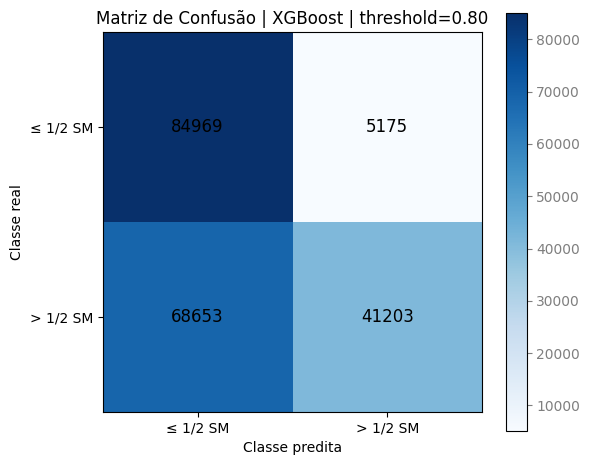

In [83]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

# ------------------------------------------------------------
# CONFIGURAÇÕES
# ------------------------------------------------------------
THRESHOLD = 0.80  

AZUL = "#1f77b4"
CINZA = "#7f7f7f"

# ------------------------------------------------------------
# 1) PREDIÇÕES NO THRESHOLD DEFINIDO
# ------------------------------------------------------------
# Probabilidade da classe positiva (1 = acima de 1/2 SM)
proba_pos = pipeline_final.predict_proba(X_test)[:, 1]

# Predição binária com threshold
y_pred = (proba_pos >= THRESHOLD).astype(int)

# ------------------------------------------------------------
# 2) MÉTRICAS NUMÉRICAS
# ------------------------------------------------------------
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
rec  = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
f1   = f1_score(y_test, y_pred, pos_label=1, zero_division=0)

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

print(f"=== Avaliação no threshold = {THRESHOLD:.2f} ===")
print(f"Acurácia            : {acc:.4f}")
print(f"Precisão (classe 1) : {prec:.4f}")
print(f"Revocação (classe 1): {rec:.4f}")
print(f"F1 (classe 1)       : {f1:.4f}")
print(f"Taxa de convocação  : {(y_pred == 1).mean():.4f}")

print("\nMatriz de confusão (valores absolutos):")
print(pd.DataFrame(
    cm,
    index=["Real ≤ 1/2 SM", "Real > 1/2 SM"],
    columns=["Pred ≤ 1/2 SM", "Pred > 1/2 SM"]
))

# ------------------------------------------------------------
# 3) PLOT DA MATRIZ DE CONFUSÃO
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")

ax.set_title(f"Matriz de Confusão | XGBoost | threshold={THRESHOLD:.2f}")
ax.set_xlabel("Classe predita")
ax.set_ylabel("Classe real")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(["≤ 1/2 SM", "> 1/2 SM"])
ax.set_yticklabels(["≤ 1/2 SM", "> 1/2 SM"])

# Anotações dentro das células
for (i, j), val in np.ndenumerate(cm):
    ax.text(j, i, int(val), ha="center", va="center", fontsize=12)

# Barra de cor (cinza discreto)
cbar = plt.colorbar(im, ax=ax)
cbar.ax.tick_params(color=CINZA)
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color=CINZA)

plt.tight_layout()
plt.show()



ROC-AUC: 0.8303


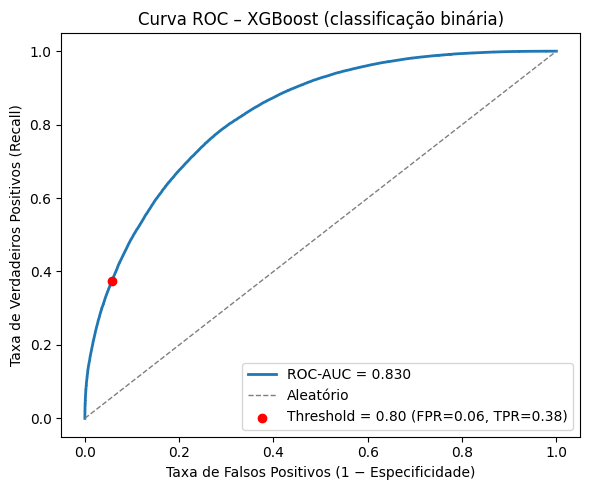

In [85]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# ------------------------------------------------------------
# CONFIGURAÇÕES
# ------------------------------------------------------------
AZUL = "#1f77b4"
CINZA = "#7f7f7f"
VERM = "red"

# ------------------------------------------------------------
# 1) PROBABILIDADES DA CLASSE POSITIVA
# ------------------------------------------------------------
proba_pos = pipeline_final.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------
# 2) CÁLCULO DA CURVA ROC E AUC
# ------------------------------------------------------------
fpr, tpr, thresholds = roc_curve(y_test, proba_pos)
roc_auc = roc_auc_score(y_test, proba_pos)
print(f"ROC-AUC: {roc_auc:.4f}")

# Ponto correspondente ao threshold 0.80
idx_thr = np.argmin(np.abs(thresholds - 0.80))
fpr_thr = fpr[idx_thr]
tpr_thr = tpr[idx_thr]

# ------------------------------------------------------------
# 3) PLOT DA CURVA ROC
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(fpr, tpr, color=AZUL, linewidth=2, label=f"ROC-AUC = {roc_auc:.3f}")

# Linha de referência (classificador aleatório)
ax.plot([0, 1], [0, 1], linestyle="--", color=CINZA, linewidth=1, label="Aleatório")

# Ponto do threshold 0.80
ax.scatter(fpr_thr, tpr_thr, color=VERM, zorder=5,
           label=f"Threshold = 0.80 (FPR={fpr_thr:.2f}, TPR={tpr_thr:.2f})")

ax.set_title("Curva ROC – XGBoost (classificação binária)")
ax.set_xlabel("Taxa de Falsos Positivos (1 − Especificidade)")
ax.set_ylabel("Taxa de Verdadeiros Positivos (Recall)")
ax.legend(loc="lower right")
ax.grid(False)
plt.tight_layout()
plt.show()


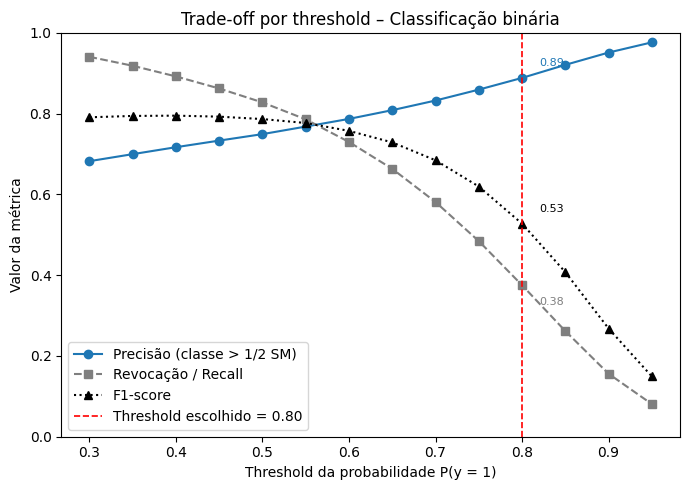

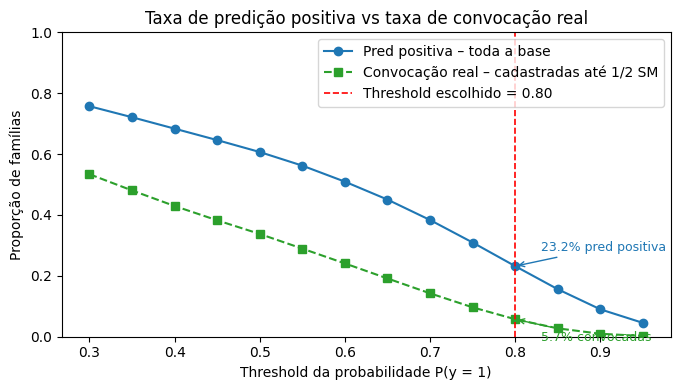

In [86]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# ------------------------------------------------------------
# CONFIGURAÇÕES
# ------------------------------------------------------------
AZUL  = "#1f77b4"
CINZA = "#7f7f7f"
PRETO = "#000000"
VERM  = "red"
VERDE = "#2ca02c"
THRESHOLD_FINAL = 0.80
THRESHOLDS = np.arange(0.30, 0.96, 0.05)

# ------------------------------------------------------------
# 1) PROBABILIDADES DA CLASSE POSITIVA
# ------------------------------------------------------------
proba_pos = pipeline_final.predict_proba(X_test)[:, 1]

# Máscara: famílias cadastradas como até 1/2 SM (classes 0 e 1)
classe_renda_test = df.loc[X_test.index, "classe_renda"]
mask_ate_meio_sm  = (classe_renda_test != 2).values

# ------------------------------------------------------------
# 2) CÁLCULO DAS MÉTRICAS POR THRESHOLD
# ------------------------------------------------------------
precisoes            = []
revocacoes           = []
f1_scores            = []
taxa_pred_positiva   = []
taxa_convocacao_real = []

for t in THRESHOLDS:
    y_pred = (proba_pos >= t).astype(int)
    precisoes.append(precision_score(y_test, y_pred, pos_label=1, zero_division=0))
    revocacoes.append(recall_score(y_test, y_pred, pos_label=1, zero_division=0))
    f1_scores.append(f1_score(y_test, y_pred, pos_label=1, zero_division=0))
    taxa_pred_positiva.append((y_pred == 1).mean())
    taxa_convocacao_real.append((y_pred[mask_ate_meio_sm] == 1).mean())

# Índice do threshold operacional
idx_thr = np.argmin(np.abs(THRESHOLDS - THRESHOLD_FINAL))

# ------------------------------------------------------------
# 3) PLOT DO TRADE-OFF (PRECISÃO, RECALL, F1)
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(THRESHOLDS, precisoes,  marker="o", color=AZUL,  label="Precisão (classe > 1/2 SM)")
ax.plot(THRESHOLDS, revocacoes, marker="s", color=CINZA, linestyle="--", label="Revocação / Recall")
ax.plot(THRESHOLDS, f1_scores,  marker="^", color=PRETO, linestyle=":",  label="F1-score")

# Linha vertical no threshold escolhido
ax.axvline(THRESHOLD_FINAL, color=VERM, linestyle="--", linewidth=1.2,
           label=f"Threshold escolhido = {THRESHOLD_FINAL:.2f}")

# Anotações no threshold escolhido
ax.annotate(f"{precisoes[idx_thr]:.2f}",
            xy=(THRESHOLD_FINAL, precisoes[idx_thr]),
            xytext=(THRESHOLD_FINAL + 0.02, precisoes[idx_thr] + 0.03),
            color=AZUL, fontsize=8)

ax.annotate(f"{revocacoes[idx_thr]:.2f}",
            xy=(THRESHOLD_FINAL, revocacoes[idx_thr]),
            xytext=(THRESHOLD_FINAL + 0.02, revocacoes[idx_thr] - 0.05),
            color=CINZA, fontsize=8)

ax.annotate(f"{f1_scores[idx_thr]:.2f}",
            xy=(THRESHOLD_FINAL, f1_scores[idx_thr]),
            xytext=(THRESHOLD_FINAL + 0.02, f1_scores[idx_thr] + 0.03),
            color=PRETO, fontsize=8)

ax.set_title("Trade-off por threshold – Classificação binária")
ax.set_xlabel("Threshold da probabilidade P(y = 1)")
ax.set_ylabel("Valor da métrica")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(False)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4) PLOT: TAXA DE PREDIÇÃO POSITIVA vs TAXA DE CONVOCAÇÃO REAL
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(THRESHOLDS, taxa_pred_positiva,   marker="o", color=AZUL,  label="Pred positiva – toda a base")
ax.plot(THRESHOLDS, taxa_convocacao_real, marker="s", color=VERDE, linestyle="--", label="Convocação real – cadastradas até 1/2 SM")

# Linha vertical no threshold escolhido
ax.axvline(THRESHOLD_FINAL, color=VERM, linestyle="--", linewidth=1.2,
           label=f"Threshold escolhido = {THRESHOLD_FINAL:.2f}")

# Anotação: taxa de predição positiva
ax.annotate(
    f"{taxa_pred_positiva[idx_thr]:.1%} pred positiva",
    xy=(THRESHOLD_FINAL, taxa_pred_positiva[idx_thr]),
    xytext=(THRESHOLD_FINAL + 0.03, taxa_pred_positiva[idx_thr] + 0.05),
    arrowprops=dict(arrowstyle="->", color=AZUL),
    color=AZUL, fontsize=9
)

# Anotação: taxa de convocação real
ax.annotate(
    f"{taxa_convocacao_real[idx_thr]:.1%} convocadas",
    xy=(THRESHOLD_FINAL, taxa_convocacao_real[idx_thr]),
    xytext=(THRESHOLD_FINAL + 0.03, taxa_convocacao_real[idx_thr] - 0.07),
    arrowprops=dict(arrowstyle="->", color=VERDE),
    color=VERDE, fontsize=9
)

ax.set_title("Taxa de predição positiva vs taxa de convocação real")
ax.set_xlabel("Threshold da probabilidade P(y = 1)")
ax.set_ylabel("Proporção de famílias")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()


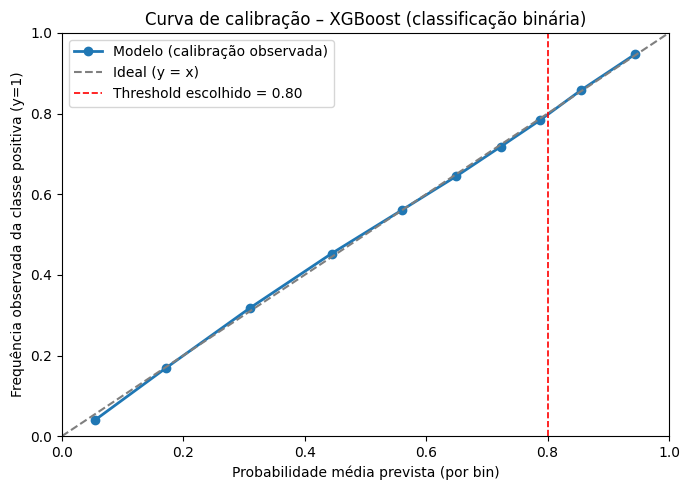

,bin,prob_media_prevista,freq_observada,dif_observada_menos_prevista
0,1,0.0548,0.0402,-0.0146
1,2,0.1723,0.1700,-0.0024
2,3,0.3098,0.3177,0.0080
3,4,0.4443,0.4528,0.0085
4,5,0.5609,0.5614,0.0005
5,6,0.6499,0.6447,-0.0052
6,7,0.7228,0.7178,-0.0050
7,8,0.7882,0.7841,-0.0041
8,9,0.8547,0.8575,0.0028
9,10,0.9439,0.9466,0.0028


In [87]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
import pandas as pd

# ------------------------------------------------------------
# CONFIGURAÇÕES
# ------------------------------------------------------------
AZUL  = "#1f77b4"
CINZA = "#7f7f7f"
VERM  = "red"
N_BINS = 10
THRESHOLD_FINAL = 0.80

# ------------------------------------------------------------
# 1) PROBABILIDADES DA CLASSE POSITIVA
# ------------------------------------------------------------
proba_pos = pipeline_final.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------
# 2) CÁLCULO DA CURVA DE CALIBRAÇÃO
# ------------------------------------------------------------
frac_pos, mean_pred = calibration_curve(
    y_test,
    proba_pos,
    n_bins=N_BINS,
    strategy="quantile"
)

# ------------------------------------------------------------
# 3) PLOT DA CURVA DE CALIBRAÇÃO
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(mean_pred, frac_pos, marker="o", color=AZUL, linewidth=2,
        label="Modelo (calibração observada)")

ax.plot([0, 1], [0, 1], linestyle="--", color=CINZA, linewidth=1.5,
        label="Ideal (y = x)")

# Marca o threshold operacional no eixo X
ax.axvline(THRESHOLD_FINAL, color=VERM, linestyle="--", linewidth=1.2,
           label=f"Threshold escolhido = {THRESHOLD_FINAL:.2f}")

ax.set_title("Curva de calibração – XGBoost (classificação binária)")
ax.set_xlabel("Probabilidade média prevista (por bin)")
ax.set_ylabel("Frequência observada da classe positiva (y=1)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(False)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4) TABELA RESUMO DOS BINS
# ------------------------------------------------------------
df_calib = pd.DataFrame({
    "bin":                          np.arange(1, len(mean_pred) + 1),
    "prob_media_prevista":          mean_pred.round(4),
    "freq_observada":               frac_pos.round(4),
    "dif_observada_menos_prevista": (frac_pos - mean_pred).round(4)
})
display(df_calib)


## Análise da importância das variáveis

In [88]:
from sklearn.inspection import permutation_importance
import pandas as pd

def plot_importancia(pipe, X, y, top_n=20, titulo="Modelo"):
    r = permutation_importance(
        pipe, X, y,
        n_repeats=5,
        random_state=42,
        scoring="f1"
    )

    feat_names = X.columns if hasattr(X, "columns") else [f"f{i}" for i in range(X.shape[1])]

    imp = (
        pd.DataFrame({
            "feature": feat_names,
            "importance": r.importances_mean
        })
        .sort_values("importance", ascending=False)
        .head(top_n)
    )

    fig, ax = plt.subplots()
    ax.barh(imp["feature"][::-1], imp["importance"][::-1], color=AZUL)
    ax.set_title(f"Importância das variáveis (Top {top_n}) | {titulo}")
    ax.set_xlabel("Queda média no F1")
    plt.show()

    return imp



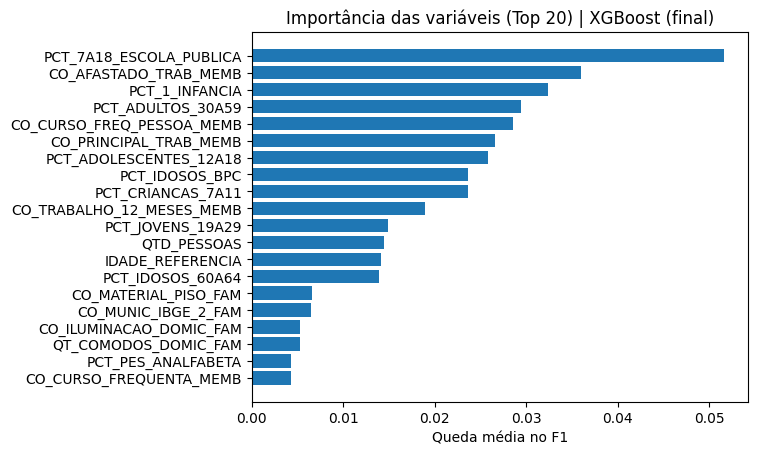

In [89]:
imp_top = plot_importancia(
    pipe=pipeline_final,
    X=X_test,
    y=y_test,
    top_n=20,
    titulo="XGBoost (final)"
)

C:\Users\Admin\AppData\Local\Temp\ipykernel_19676\210754078.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot.groupby(["bin", target])


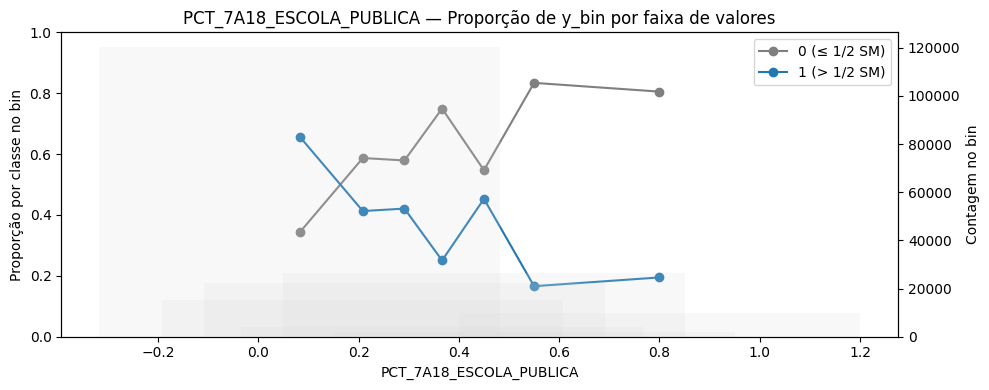

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# CONFIG
# -----------------------------
AZUL = "#1f77b4"
CINZA = "#7f7f7f"
CINZA_CLARO = "#d9d9d9"

col = "PCT_7A18_ESCOLA_PUBLICA"   # <- variável do gráfico
target = "y_bin"                  # <- binário: 0/1
CLASSES = [0, 1]
N_BINS = 20

# -----------------------------
# BASE PARA PLOT
# -----------------------------
df_plot = X_test[[col]].copy()
df_plot[target] = y_test  # y_test deve ser y_bin

df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce")
df_plot = df_plot.dropna(subset=[col, target])

# cria bins por quantis
q = min(N_BINS, df_plot[col].nunique())
df_plot["bin"] = pd.qcut(df_plot[col], q=q, duplicates="drop")

# tabela e proporções por bin
tab = (
    df_plot.groupby(["bin", target])
           .size()
           .unstack(fill_value=0)
           .reindex(columns=CLASSES, fill_value=0)
)

prop = tab.div(tab.sum(axis=1), axis=0)

# centros dos bins e contagem
centers = np.array([(b.left + b.right) / 2 for b in prop.index])
counts = tab.sum(axis=1).to_numpy()

# -----------------------------
# PLOT
# -----------------------------
fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(
    centers, prop[0].to_numpy(),
    marker="o", linewidth=1.5, color=CINZA,
    label="0 (≤ 1/2 SM)"
)

ax1.plot(
    centers, prop[1].to_numpy(),
    marker="o", linewidth=1.5, color=AZUL,
    label="1 (> 1/2 SM)"
)

ax1.set_ylim(0, 1)
ax1.set_xlabel(col)
ax1.set_ylabel("Proporção por classe no bin")
ax1.set_title(f"{col} — Proporção de y_bin por faixa de valores")
ax1.legend(loc="upper right")
ax1.grid(False)

ax2 = ax1.twinx()
ax2.bar(centers, counts, alpha=0.18, color=CINZA_CLARO)
ax2.set_ylabel("Contagem no bin")

plt.tight_layout()
plt.show()



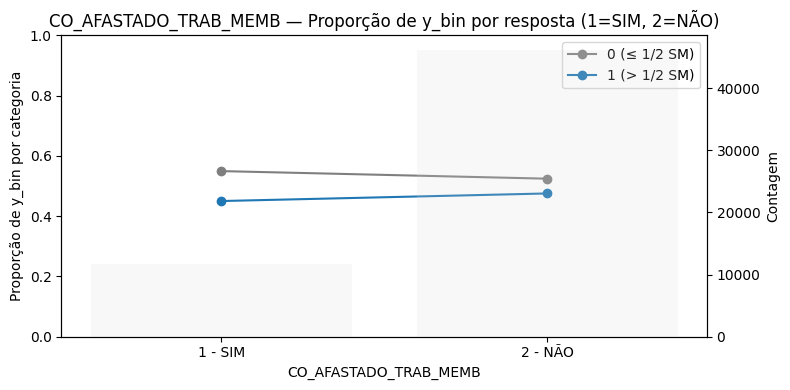

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# CONFIG
# -----------------------------
AZUL = "#1f77b4"
CINZA = "#7f7f7f"
CINZA_CLARO = "#d9d9d9"

col = "CO_AFASTADO_TRAB_MEMB"   # 1=SIM, 2=NÃO
target = "y_bin"                # 0/1

# mapa de rótulos (ajuste se houver outros códigos)
mapa_col = {1: "1 - SIM", 2: "2 - NÃO"}
mapa_y = {0: "0 (≤ 1/2 SM)", 1: "1 (> 1/2 SM)"}

# -----------------------------
# BASE PARA PLOT
# -----------------------------
df_plot = X_test[[col]].copy()
df_plot[target] = y_test  # y_test deve ser y_bin

df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce")
df_plot = df_plot.dropna(subset=[col, target])

# manter apenas 1 e 2 (opcional, mas recomendado)
df_plot = df_plot[df_plot[col].isin([1, 2])].copy()

# aplicar rótulos
df_plot["categoria"] = df_plot[col].map(mapa_col).fillna(df_plot[col].astype(int).astype(str))

# -----------------------------
# TABELA: contagem e proporção por categoria
# -----------------------------
tab = (
    df_plot.groupby(["categoria", target])
           .size()
           .unstack(fill_value=0)
           .reindex(columns=[0, 1], fill_value=0)
)

prop = tab.div(tab.sum(axis=1), axis=0)
counts = tab.sum(axis=1)

# ordenar categorias (SIM primeiro, depois NÃO)
ordem = ["1 - SIM", "2 - NÃO"]
prop = prop.reindex([c for c in ordem if c in prop.index] + [c for c in prop.index if c not in ordem])
counts = counts.reindex(prop.index)

# -----------------------------
# PLOT
# -----------------------------
x = np.arange(len(prop.index))

fig, ax1 = plt.subplots(figsize=(8, 4))

# proporções (linhas ou barras). Aqui mantive linhas para "mesma lógica" do seu gráfico.
ax1.plot(x, prop[0].to_numpy(), marker="o", linewidth=1.5, color=CINZA, label=mapa_y[0])
ax1.plot(x, prop[1].to_numpy(), marker="o", linewidth=1.5, color=AZUL,  label=mapa_y[1])

ax1.set_ylim(0, 1)
ax1.set_xticks(x)
ax1.set_xticklabels(prop.index)
ax1.set_xlabel(col)
ax1.set_ylabel("Proporção de y_bin por categoria")
ax1.set_title(f"{col} — Proporção de y_bin por resposta (1=SIM, 2=NÃO)")
ax1.legend(loc="upper right")
ax1.grid(False)

# contagem no eixo secundário
ax2 = ax1.twinx()
ax2.bar(x, counts.to_numpy(), alpha=0.18, color=CINZA_CLARO)
ax2.set_ylabel("Contagem")

plt.tight_layout()
plt.show()



C:\Users\Admin\AppData\Local\Temp\ipykernel_19676\658949938.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot.groupby(["bin", target])


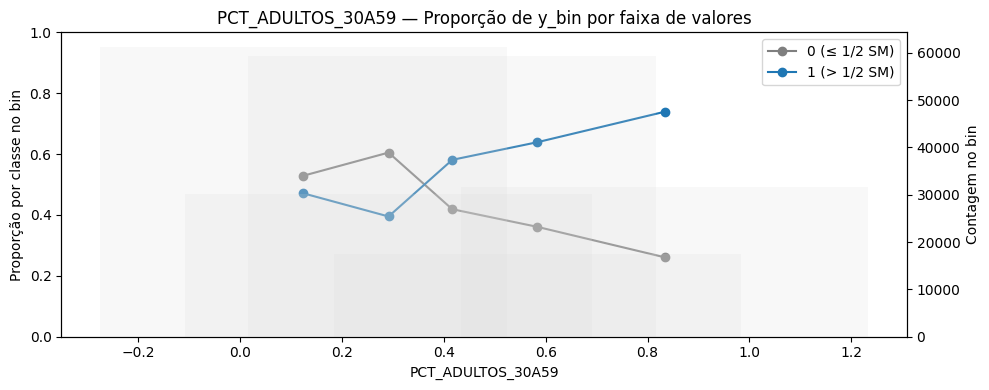

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# CONFIG
# -----------------------------
AZUL = "#1f77b4"
CINZA = "#7f7f7f"
CINZA_CLARO = "#d9d9d9"

col = "PCT_ADULTOS_30A59"   # <- variável do gráfico
target = "y_bin"                  # <- binário: 0/1
CLASSES = [0, 1]
N_BINS = 20

# -----------------------------
# BASE PARA PLOT
# -----------------------------
df_plot = X_test[[col]].copy()
df_plot[target] = y_test  # y_test deve ser y_bin

df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce")
df_plot = df_plot.dropna(subset=[col, target])

# cria bins por quantis
q = min(N_BINS, df_plot[col].nunique())
df_plot["bin"] = pd.qcut(df_plot[col], q=q, duplicates="drop")

# tabela e proporções por bin
tab = (
    df_plot.groupby(["bin", target])
           .size()
           .unstack(fill_value=0)
           .reindex(columns=CLASSES, fill_value=0)
)

prop = tab.div(tab.sum(axis=1), axis=0)

# centros dos bins e contagem
centers = np.array([(b.left + b.right) / 2 for b in prop.index])
counts = tab.sum(axis=1).to_numpy()

# -----------------------------
# PLOT
# -----------------------------
fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(
    centers, prop[0].to_numpy(),
    marker="o", linewidth=1.5, color=CINZA,
    label="0 (≤ 1/2 SM)"
)

ax1.plot(
    centers, prop[1].to_numpy(),
    marker="o", linewidth=1.5, color=AZUL,
    label="1 (> 1/2 SM)"
)

ax1.set_ylim(0, 1)
ax1.set_xlabel(col)
ax1.set_ylabel("Proporção por classe no bin")
ax1.set_title(f"{col} — Proporção de y_bin por faixa de valores")
ax1.legend(loc="upper right")
ax1.grid(False)

ax2 = ax1.twinx()
ax2.bar(centers, counts, alpha=0.18, color=CINZA_CLARO)
ax2.set_ylabel("Contagem no bin")

plt.tight_layout()
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_19676\1245142794.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot.groupby(["bin", target])


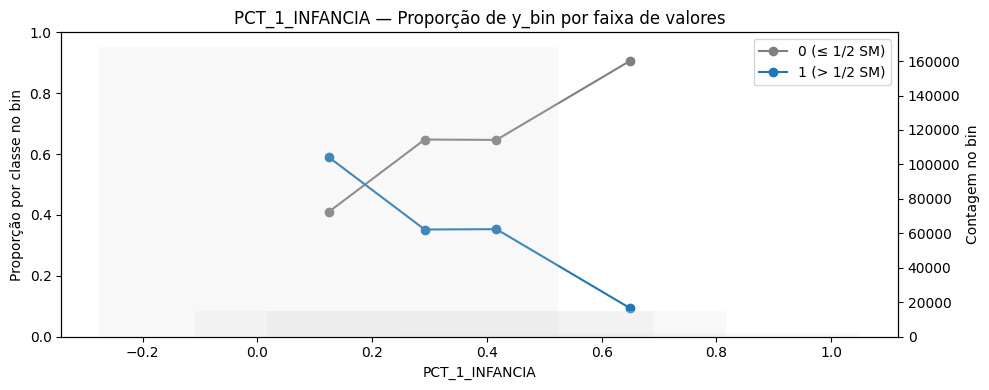

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# CONFIG
# -----------------------------
AZUL = "#1f77b4"
CINZA = "#7f7f7f"
CINZA_CLARO = "#d9d9d9"

col = "PCT_1_INFANCIA"   # <- variável do gráfico
target = "y_bin"                  # <- binário: 0/1
CLASSES = [0, 1]
N_BINS = 20

# -----------------------------
# BASE PARA PLOT
# -----------------------------
df_plot = X_test[[col]].copy()
df_plot[target] = y_test  # y_test deve ser y_bin

df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce")
df_plot = df_plot.dropna(subset=[col, target])

# cria bins por quantis
q = min(N_BINS, df_plot[col].nunique())
df_plot["bin"] = pd.qcut(df_plot[col], q=q, duplicates="drop")

# tabela e proporções por bin
tab = (
    df_plot.groupby(["bin", target])
           .size()
           .unstack(fill_value=0)
           .reindex(columns=CLASSES, fill_value=0)
)

prop = tab.div(tab.sum(axis=1), axis=0)

# centros dos bins e contagem
centers = np.array([(b.left + b.right) / 2 for b in prop.index])
counts = tab.sum(axis=1).to_numpy()

# -----------------------------
# PLOT
# -----------------------------
fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(
    centers, prop[0].to_numpy(),
    marker="o", linewidth=1.5, color=CINZA,
    label="0 (≤ 1/2 SM)"
)

ax1.plot(
    centers, prop[1].to_numpy(),
    marker="o", linewidth=1.5, color=AZUL,
    label="1 (> 1/2 SM)"
)

ax1.set_ylim(0, 1)
ax1.set_xlabel(col)
ax1.set_ylabel("Proporção por classe no bin")
ax1.set_title(f"{col} — Proporção de y_bin por faixa de valores")
ax1.legend(loc="upper right")
ax1.grid(False)

ax2 = ax1.twinx()
ax2.bar(centers, counts, alpha=0.18, color=CINZA_CLARO)
ax2.set_ylabel("Contagem no bin")

plt.tight_layout()
plt.show()

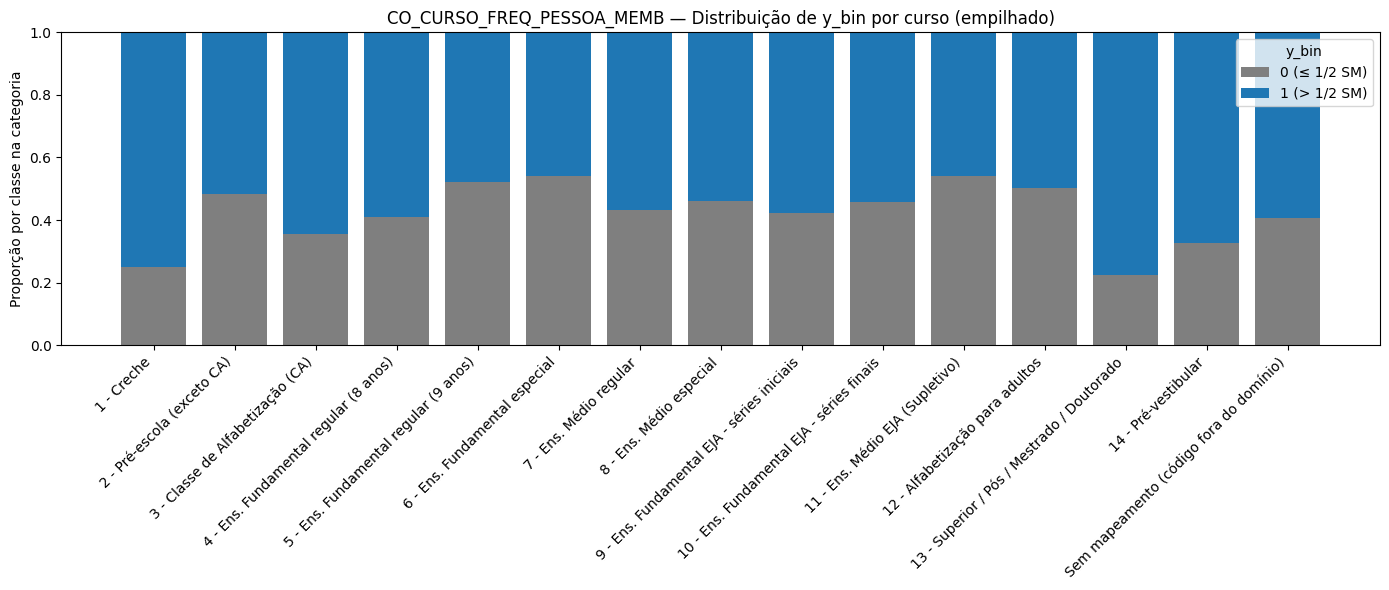

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# CONFIG
# -----------------------------
col = "CO_CURSO_FREQ_PESSOA_MEMB"

# >>> ESCOLHA O TARGET AQUI <<<
target = "y_bin"           # binário (0/1) | alternativa: "classe_renda"
CLASSES = [0, 1]           # se target="classe_renda", use: [0, 1, 2]

TOP_CAT = 20
MIN_COUNT = 50

AZUL = "#1f77b4"
CINZA = "#7f7f7f"
AZUL_ESCURO = "#0b2d5b"

# -----------------------------
# MAPEAMENTO (códigos oficiais)
# -----------------------------
map_curso = {
    1:  "1 - Creche",
    2:  "2 - Pré-escola (exceto CA)",
    3:  "3 - Classe de Alfabetização (CA)",
    4:  "4 - Ens. Fundamental regular (8 anos)",
    5:  "5 - Ens. Fundamental regular (9 anos)",
    6:  "6 - Ens. Fundamental especial",
    7:  "7 - Ens. Médio regular",
    8:  "8 - Ens. Médio especial",
    9:  "9 - Ens. Fundamental EJA - séries iniciais",
    10: "10 - Ens. Fundamental EJA - séries finais",
    11: "11 - Ens. Médio EJA (Supletivo)",
    12: "12 - Alfabetização para adultos",
    13: "13 - Superior / Pós / Mestrado / Doutorado",
    14: "14 - Pré-vestibular",
}

CODIGOS_VALIDOS = set(map_curso.keys())

# -----------------------------
# DADOS
# -----------------------------
df_plot = X_test[[col]].copy()
df_plot[target] = y_test

df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce")

# coluna de trabalho (código categórico)
df_plot["categoria_cod"] = df_plot[col]

# marcar códigos fora do domínio como -2
df_plot.loc[
    ~df_plot["categoria_cod"].isin(CODIGOS_VALIDOS) & df_plot["categoria_cod"].notna(),
    "categoria_cod"
] = -2

# agrupar raras APENAS entre códigos válidos
vc_valid = df_plot.loc[df_plot["categoria_cod"].isin(CODIGOS_VALIDOS), "categoria_cod"].value_counts()
raras = []

# códigos raros -> OUTROS (-1)
df_plot.loc[df_plot["categoria_cod"].isin(raras), "categoria_cod"] = -1

# rótulo final
def rotular(c):
    if pd.isna(c):
        return "Sem informação"
    c = int(c)
    #if c == -1:
        #return "OUTROS (códigos raros)"
    if c == -2:
        return "Sem mapeamento (código fora do domínio)"
    return map_curso.get(c, "Sem mapeamento (código fora do domínio)")

df_plot["rotulo"] = df_plot["categoria_cod"].apply(rotular)

# top categorias por frequência (para não poluir)
top = df_plot["rotulo"].value_counts().head(TOP_CAT).index
df_plot = df_plot[df_plot["rotulo"].isin(top)].copy()

# -----------------------------
# PROPORÇÕES POR CLASSE DENTRO DE CADA CATEGORIA
# -----------------------------
tab = (
    df_plot.groupby(["rotulo", target]).size()
    .unstack(fill_value=0)
    .reindex(columns=CLASSES, fill_value=0)
)
prop = tab.div(tab.sum(axis=1), axis=0)

# ordenação por código
def ordem_rotulo(r):
    if r.startswith("OUTROS"):
        return 900
    if r.startswith("Sem mapeamento"):
        return 950
    if r == "Sem informação":
        return 999
    try:
        return int(str(r).split(" - ", 1)[0])
    except Exception:
        return 998

prop = prop.loc[sorted(prop.index, key=ordem_rotulo)]

# -----------------------------
# PLOT (empilhado)
# -----------------------------
if CLASSES == [0, 1]:
    cores = {0: CINZA, 1: AZUL}
    legendas = {0: "0 (≤ 1/2 SM)", 1: "1 (> 1/2 SM)"}
    legend_title = "y_bin"
else:
    cores = {0: AZUL, 1: CINZA, 2: AZUL_ESCURO}
    legendas = {0: "0", 1: "1", 2: "2"}
    legend_title = "classe_renda"

x = np.arange(len(prop.index))
bottom = np.zeros(len(prop.index))

plt.figure(figsize=(14, 6))
for k in CLASSES:
    vals = prop[k].to_numpy()
    plt.bar(x, vals, bottom=bottom, label=legendas.get(k, str(k)), color=cores[k])
    bottom += vals

plt.xticks(x, prop.index, rotation=45, ha="right")
plt.ylim(0, 1)
plt.ylabel("Proporção por classe na categoria")
plt.title(f"{col} — Distribuição de {target} por curso (empilhado)")
plt.legend(title=legend_title, loc="upper right")
plt.tight_layout()
plt.show()



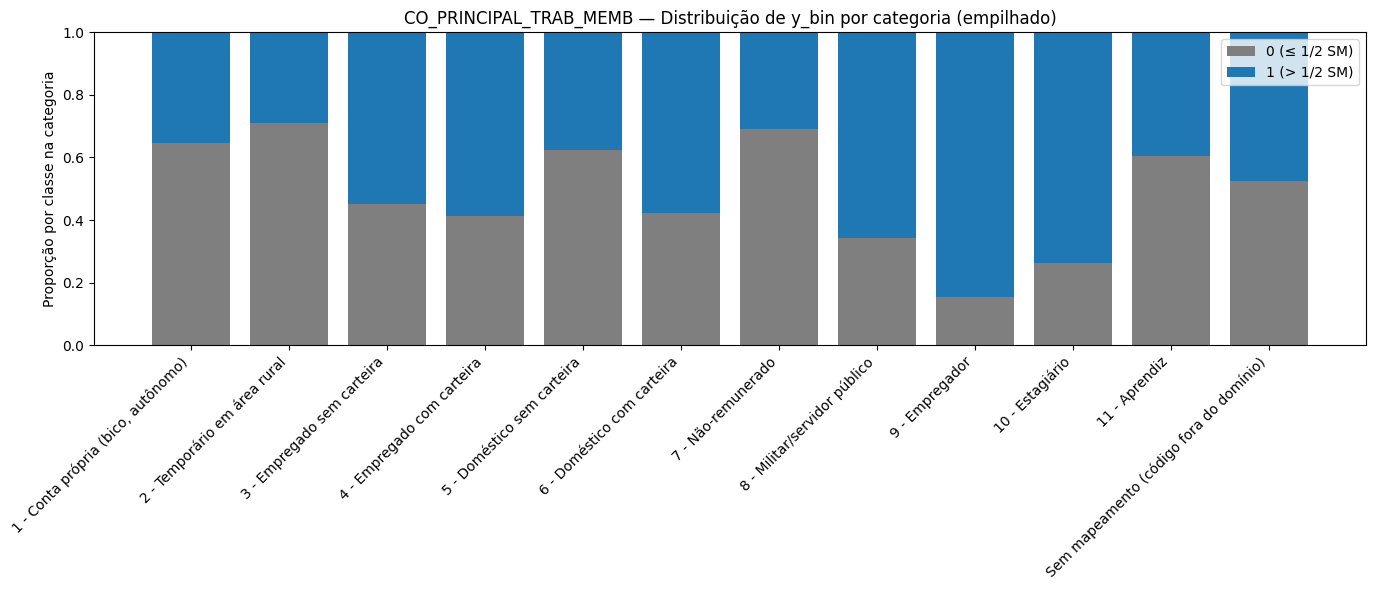

In [58]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt


# ----------------------------- 
# CONFIG 
# ----------------------------- 
col = "CO_PRINCIPAL_TRAB_MEMB" 

# >>> ESCOLHA O TARGET AQUI <<< 
target = "y_bin" # binário (0/1) 
CLASSES = [0, 1] 

TOP_CAT = 20 
MIN_COUNT = 50 

AZUL = "#1f77b4" 
CINZA = "#7f7f7f" 
AZUL_ESCURO = "#0b2d5b" 
CINZA_CLARO = "#d9d9d9" 


# ----------------------------- 
# MAPEAMENTO (códigos oficiais) 
# ----------------------------- 

map_trab = { 
    1: "1 - Conta própria (bico, autônomo)", 
    2: "2 - Temporário em área rural", 
    3: "3 - Empregado sem carteira", 
    4: "4 - Empregado com carteira", 
    5: "5 - Doméstico sem carteira", 
    6: "6 - Doméstico com carteira", 
    7: "7 - Não-remunerado", 
    8: "8 - Militar/servidor público", 
    9: "9 - Empregador", 
    10: "10 - Estagiário", 
    11: "11 - Aprendiz", 
} 

CODIGOS_VALIDOS = set(map_trab.keys())

# ----------------------------- 
# DADOS 
# ----------------------------- 
df_plot = X_test[[col]].copy() 
df_plot[target] = y_test 

# numérico (se vier como object) 
df_plot[col] = pd.to_numeric(df_plot[col], errors="coerce") 


# separar sem informação (NaN) 
df_plot["categoria_cod"] = df_plot[col] 


# marcar códigos fora do domínio como "Sem mapeamento" 
df_plot.loc[~df_plot["categoria_cod"].isin(CODIGOS_VALIDOS) & 
df_plot["categoria_cod"].notna(), "categoria_cod"] = -2 


# agora agrupar raras APENAS entre códigos válidos 
vc_valid = df_plot.loc[df_plot["categoria_cod"].isin(CODIGOS_VALIDOS), 
"categoria_cod"].value_counts() 
raras = [] 

# códigos raros vão para OUTROS (-1) 
#df_plot.loc[df_plot["categoria_cod"].isin(raras), "categoria_cod"] = -1 


# criar rótulo final 
def rotular(c): 
    if pd.isna(c): 
        return "Sem informação" 
    c = int(c) 
    #if c == -1: 
        #return "OUTROS (códigos raros)" 
    if c == -2: 
        return "Sem mapeamento (código fora do domínio)" 
    return map_trab.get(c, "Sem mapeamento (código fora do domínio)") 

df_plot["rotulo"] = df_plot["categoria_cod"].apply(rotular) 


# selecionar top categorias por frequência (para não poluir) 
top = df_plot["rotulo"].value_counts().head(TOP_CAT).index 
df_plot = df_plot[df_plot["rotulo"].isin(top)].copy() 


# ----------------------------- 
# TABELA: proporção por classe dentro de cada categoria 
# ----------------------------- 
tab = ( 
    df_plot.groupby(["rotulo", target]).size()
    .unstack(fill_value=0)
    .reindex(columns=CLASSES, fill_value=0) 
) 
prop = tab.div(tab.sum(axis=1), axis=0) 

# ordenar por código (1..11), depois OUTROS, Sem mapeamento, Sem informação 
def ordem_rotulo(r): 
    if r.startswith("OUTROS"): 
        return 900 
    if r.startswith("Sem mapeamento"): 
        return 950 
    if r == "Sem informação": 
        return 999 
    try: 
        return int(str(r).split(" - ", 1)[0]) 
    except Exception: 
        return 998 
        
prop = prop.loc[sorted(prop.index, key=ordem_rotulo)] 

# ----------------------------- 
# PLOT (empilhado) 
# ----------------------------- 
# cores por classe 
if CLASSES == [0, 1]: 
    cores = {0: CINZA, 1: AZUL} 
    legendas = {0: "0 (≤ 1/2 SM)", 1: "1 (> 1/2 SM)"} 
else: 
    cores = {0: AZUL, 1: CINZA, 2: AZUL_ESCURO} 
    legendas = {0: "0", 1: "1", 2: "2"} 

x = np.arange(len(prop.index)) 
bottom = np.zeros(len(prop.index)) 

plt.figure(figsize=(14, 6)) 
for k in CLASSES: 
    vals = prop[k].to_numpy() 
    plt.bar(x, vals, bottom=bottom, label=legendas.get(k, str(k)), color=cores[k]) 
    bottom += vals 

plt.xticks(x, prop.index, rotation=45, ha="right") 
plt.ylim(0, 1) 
plt.ylabel("Proporção por classe na categoria") 
plt.title(f"{col} — Distribuição de {target} por categoria (empilhado)") 
plt.legend(loc="upper right") 
plt.tight_layout() 
plt.show()



## Análises adicionais considerando as classes de renda originais

In [59]:
THR = 0.80

df_test = df.loc[X_test.index, ["classe_renda"]].copy()

df_test["y_bin"] = y_test
df_test["proba_pos"] = pipeline_final.predict_proba(X_test)[:, 1]
df_test["y_pred_thr"] = (df_test["proba_pos"] >= THR).astype(int)

# flags de avaliação
df_test["TP"] = (df_test["y_bin"]==1) & (df_test["y_pred_thr"]==1)
df_test["FP"] = (df_test["y_bin"]==0) & (df_test["y_pred_thr"]==1)
df_test["FN"] = (df_test["y_bin"]==1) & (df_test["y_pred_thr"]==0)
df_test["TN"] = (df_test["y_bin"]==0) & (df_test["y_pred_thr"]==0)

df_test.head()



,classe_renda,y_bin,proba_pos,y_pred_thr,TP,FP,FN,TN
731839,2,1,0.608934,0,False,False,True,False
746576,2,1,0.472080,0,False,False,True,False
26786,1,0,0.445056,0,False,False,False,True
713125,2,1,0.562629,0,False,False,True,False
118427,1,0,0.572553,0,False,False,False,True


In [60]:
assert len(df_test) == len(X_test) == len(y_test)
df_test["classe_renda"].value_counts()


classe_renda
2    109856
1     62593
0     27551
Name: count, dtype: int64

### Distribuição de classe_renda por predição (convocados vs não)

In [61]:
tab = pd.crosstab(df_test["classe_renda"], df_test["y_pred_thr"], normalize="columns")
tab.columns = ["Não convocado (pred=0)", "Convocado (pred=1)"]
tab

,Não convocado (pred=0),Convocado (pred=1)
classe_renda,,
0,0.173979,0.017767
1,0.379125,0.093816
2,0.446896,0.888417


In [62]:
pd.crosstab(df_test["classe_renda"], df_test["y_pred_thr"])

y_pred_thr,0,1
classe_renda,,
0,26727,824
1,58242,4351
2,68653,41203


### Perfil do risco (proba) dentro de cada classe_renda

In [63]:
df_test.groupby("classe_renda")["proba_pos"].agg(
    media="mean",
    p25=lambda s: s.quantile(0.25),
    mediana="median",
    p75=lambda s: s.quantile(0.75),
    p90=lambda s: s.quantile(0.90),
    n="size"
)

,media,p25,mediana,p75,p90,n
classe_renda,,,,,,
0,0.269670,0.059902,0.179228,0.447156,0.668251,27551
1,0.412967,0.185974,0.394258,0.629368,0.766230,62593
2,0.698654,0.583635,0.742275,0.855283,0.935276,109856


### Avaliação no subconjunto classe_renda == 0 (pobreza)

In [64]:
sub = df_test[df_test["classe_renda"] == 0]

res = {
    "thr": THR,
    "n": len(sub),
    "taxa_convocacao": sub["y_pred_thr"].mean(),
    "precision_pos": sub["TP"].sum() / (sub["TP"].sum() + sub["FP"].sum()) if (sub["TP"].sum() + sub["FP"].sum())>0 else np.nan,
    "recall_pos": sub["TP"].sum() / (sub["TP"].sum() + sub["FN"].sum()) if (sub["TP"].sum() + sub["FN"].sum())>0 else np.nan,
    "TP": int(sub["TP"].sum()),
    "FP": int(sub["FP"].sum()),
    "FN": int(sub["FN"].sum()),
    "TN": int(sub["TN"].sum()),
}
pd.Series(res)

thr                    0.800000
n                  27551.000000
taxa_convocacao        0.029908
precision_pos          0.000000
recall_pos                  NaN
TP                     0.000000
FP                   824.000000
FN                     0.000000
TN                 26727.000000
dtype: float64

### Perfil de classe_renda dentro dos Falsos Positivos (FP)

In [65]:
fp = df_test[df_test["FP"]]
fp["classe_renda"].value_counts(normalize=True).sort_index()


classe_renda
0    0.159227
1    0.840773
Name: proportion, dtype: float64

In [66]:
fp["classe_renda"].value_counts().sort_index()

classe_renda
0     824
1    4351
Name: count, dtype: int64

### Perfil dos Falsos Negativos (FN) dentro de classe_renda == 2

In [67]:
fn2 = df_test[(df_test["FN"]) & (df_test["classe_renda"] == 2)]
fn2.shape, fn2["proba_pos"].describe()

((68653, 8),
 count    68653.000000
 mean         0.583306
 std          0.178024
 min          0.004219
 25%          0.478535
 50%          0.633301
 75%          0.726415
 max          0.799999
 Name: proba_pos, dtype: float64)

In [68]:
tp2 = df_test[(df_test["TP"]) & (df_test["classe_renda"] == 2)]
pd.DataFrame({
    "FN_cl2_proba": fn2["proba_pos"].describe(),
    "TP_cl2_proba": tp2["proba_pos"].describe()
})

,FN_cl2_proba,TP_cl2_proba
count,68653.000000,41203.000000
mean,0.583306,0.890847
std,0.178024,0.057697
min,0.004219,0.800000
25%,0.478535,0.841299
50%,0.633301,0.883757
75%,0.726415,0.939663
max,0.799999,0.999426


### Sensibilidade ao threshold por classe_renda (0.75/0.80/0.85)

In [69]:
thresholds = [0.75, 0.80, 0.85]
rows = []

for t in thresholds:
    pred = (df_test["proba_pos"] >= t).astype(int)
    tmp = df_test.copy()
    tmp["pred"] = pred

    out = tmp.groupby("classe_renda")["pred"].mean().rename("taxa_convocacao").reset_index()
    out["threshold"] = t
    rows.append(out)

pd.concat(rows, ignore_index=True).pivot(index="classe_renda", columns="threshold", values="taxa_convocacao")

threshold,0.75,0.80,0.85
classe_renda,,,
0,0.052448,0.029908,0.012776
1,0.115955,0.069513,0.033918
2,0.484279,0.375064,0.261633


### “Precisão esperada” por threshold no grupo pobreza (classe 0)

In [70]:
thresholds = [0.75, 0.80, 0.85]
rows = []

for t in thresholds:
    pred = (df_test["proba_pos"] >= t).astype(int)
    sub = df_test[df_test["classe_renda"] == 0].copy()
    TP = ((sub["y_bin"]==1) & (pred[sub.index]==1)).sum()
    FP = ((sub["y_bin"]==0) & (pred[sub.index]==1)).sum()

    prec = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    conv = (pred[sub.index]==1).mean()

    rows.append({"threshold": t, "precision_pos_pobreza": prec, "taxa_convocacao_pobreza": conv})

pd.DataFrame(rows)


,threshold,precision_pos_pobreza,taxa_convocacao_pobreza
0,0.75,0.0,0.052448
1,0.80,0.0,0.029908
2,0.85,0.0,0.012776


### Criar grupos operacionais (classe_renda × convocação × risco)

In [71]:
df_test["faixa_risco"] = pd.cut(
    df_test["proba_pos"],
    bins=[-np.inf, 0.50, THR, np.inf],
    labels=["Baixo (<0.50)", f"Médio (0.50–{THR:.2f})", f"Alto (≥{THR:.2f})"]
)

tipologia = pd.crosstab(
    [df_test["classe_renda"], df_test["faixa_risco"]],
    df_test["y_pred_thr"],
    normalize="index"
)

tipologia.columns = ["Não convocado", "Convocado"]
tipologia

Não convocado  Convocado
classe_renda faixa_risco                                
0            Baixo (<0.50)                1.0        0.0
             Médio (0.50–0.80)            1.0        0.0
             Alto (≥0.80)                 0.0        1.0
1            Baixo (<0.50)                1.0        0.0
             Médio (0.50–0.80)            1.0        0.0
             Alto (≥0.80)                 0.0        1.0
2            Baixo (<0.50)                1.0        0.0
             Médio (0.50–0.80)            1.0        0.0
             Alto (≥0.80)                 0.0        1.0

In [72]:
pd.crosstab([df_test["classe_renda"], df_test["faixa_risco"]], df_test["y_pred_thr"])

y_pred_thr                          0      1
classe_renda faixa_risco                    
0            Baixo (<0.50)      21638      0
             Médio (0.50–0.80)   5089      0
             Alto (≥0.80)           0    824
1            Baixo (<0.50)      38070      0
             Médio (0.50–0.80)  20172      0
             Alto (≥0.80)           0   4351
2            Baixo (<0.50)      18933      0
             Médio (0.50–0.80)  49720      0
             Alto (≥0.80)           0  41203

## Salvando o modelo final

In [73]:
import os
from pathlib import Path

# importa a classe para o pickle conseguir reconstruir o objeto
from models.xgb_threshold import XGBoostComThreshold

import joblib

PATH_MODEL = Path("models") / "pipeline_xgb_binario_thr080.joblib"
pipeline = joblib.load(PATH_MODEL)

pipeline


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('quant',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   MinMaxScaler())]),
                                                  ['QT_PESSOAS_DOMIC_FAM',
                                                   'QT_FAMILIAS_DOMIC_FAM',
                                                   'QT_COMODOS_DOMIC_FAM',
                                                   'QT_COMODOS_DORMITORIO_FAM',
                                                   'QTD_PESSOAS',
                                                   'IDADE_REFERENCIA']),
                                                 ('pct', 'passthrough',
                                                  ['PCT_1_INFANCIA',
                                                   'PCT_CRIANCAS_7A11'...
                                                   'CO_ESCOA_SANITARIO_DOMIC_FAM',
                                                   'CO_ILUMINACAO_DOMIC_FAM',
                                                   'IN_PARC_MDS_FAM',
                                                   'CO_RACA_COR_PESSOA',
                                                   'IN_FREQUENTA_ESCOLA_MEMB',
                                                   'CO_CURSO_FREQUENTA_MEMB',
                                                   'CO_CURSO_FREQ_PESSOA_MEMB',
                                                   'CO_AFASTADO_TRAB_MEMB',
                                                   'CO_PRINCIPAL_TRAB_MEMB',
                                                   'CO_TRABALHO_12_MESES_MEMB']),
                                                 ('geo', 'passthrough',
                                                  ['CO_MUNIC_IBGE_2_FAM',
                                                   'CO_MUNIC_IBGE_5_FAM'])])),
                ('model', XGBoostComThreshold())])

In [74]:
from pathlib import Path

# garante que a classe custom existe como módulo importável (essencial p/ joblib depois)
from models.xgb_threshold import XGBoostComThreshold

# pasta padrão do projeto
DIR_MODELS = Path("models")
DIR_MODELS.mkdir(exist_ok=True)

# nome padronizado do arquivo do pipeline
MODEL_NAME = "pipeline_xgb_binario_thr080"
PATH_MODEL = DIR_MODELS / f"{MODEL_NAME}.joblib"

print("Modelo será salvo em:", PATH_MODEL)


Modelo será salvo em: models\pipeline_xgb_binario_thr080.joblib


In [75]:
import os
from pathlib import Path
import joblib
import pandas as pd


# importante: importar a classe custom antes do load
from models.xgb_threshold import XGBoostComThreshold

# carregar modelo já treinado
PATH_MODEL = Path("models") / "pipeline_xgb_binario_thr080.joblib"
pipeline = joblib.load(PATH_MODEL)

# carregar base de aplicação
PATH_APLIC = Path("fam_pes_cad_11_25_amostra_aplicacao.csv")
df_app = pd.read_csv(PATH_APLIC)

# aplicar
proba = pipeline.predict_proba(df_app)[:, 1]
pred  = pipeline.predict(df_app)

df_out = df_app.copy()
df_out["PROB_RENDA_INFORMAL"] = proba
df_out["PRED_RENDA_INFORMAL"] = pred

df_out.to_csv("fam_pes_cad_11_25_resultado_ml.csv", index=False)
print("✅ Salvo:", "fam_pes_cad_11_25_resultado_ml.csv")


✅ Salvo: fam_pes_cad_11_25_resultado_ml.csv
